 # <mark style="background: #ff0101ff;">Objectif : predire le prix d'une course de Taxi</mark>

### <mark style="background: #01ff1fff;">Contexte du jeu de données Taxi Trips 2024 (Chicago)</mark>
**Description générale**
Le jeu de données Taxi Trips 2024 contient les courses de taxi enregistrées dans la ville de Chicago à partir de janvier 2024. Les informations proviennent du processus de reporting des chauffeurs et des compagnies de taxi auprès de la municipalité.

**Particularités et limites**
- Certaines informations sont modifiées afin de protéger la vie privée des passagers et chauffeurs.
- Les identifiants des taxis ne correspondent pas aux numéros réels de médaillon, mais restent cohérents pour un même véhicule.
- Les informations géographiques fines (comme les Census Tracts) sont absentes ou agrégées.
- Les horaires sont arrondis à des intervalles de 15 minutes.
- Toutes les courses ne sont pas nécessairement reportées, même si la ville estime que la majorité l’est.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
# import xgboost as xgb, XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
# import shap

# <mark style="background: #01b3ffff;">Nettoyage Préliminaire de la Base</mark> 

### 1. Compréhension initiale du dataset

In [2]:
df = pd.read_csv("../data/Taxi_Trips_(2024-)_20251120.csv",sep=",")

C:\Users\maserati\AppData\Local\Temp\ipykernel_6044\1583862138.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Taxi_Trips_(2024-)_20251120.csv",sep=",")


In [3]:
pd.set_option('display.max_columns', None)

df.head(20)

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,fe0d164107a035984123dd54c9d786d442de0b44,d6e1a9e103336c396201abe9ceb00795fcd41e14ccbf54...,11/01/2025 12:00:00 AM,11/01/2025 12:15:00 AM,"1,015",4.77,NaN,NaN,32.0,24.0,$17.17,$0.00,$0.00,$0.00,$17.67,Mobile,Flash Cab,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.901207,-87.676356,POINT (-87.6763559892 41.9012069941)
1,fe5cef439c882c0fbc46fb6bad0617b8ecd48499,75ff7e74c62fa9fb70671ee63e3c87153b3037fe0c7490...,11/01/2025 12:00:00 AM,11/01/2025 12:00:00 AM,595,4.12,NaN,NaN,22.0,16.0,$12.50,$0.00,$0.00,$0.00,$13.00,Mobile,Flash Cab,41.922761,-87.699155,POINT (-87.6991553432 41.9227606205),41.953582,-87.723452,POINT (-87.7234523905 41.9535821253)
2,7f72c6c670cbb921efef198c3549b9a5d25afbaf,7cb607b940a690e65b20dec20182d2646d3306f725130c...,11/01/2025 12:00:00 AM,11/01/2025 12:30:00 AM,"1,853",17.63,1.703198e+10,1.703132e+10,76.0,32.0,$44.50,$7.65,$0.00,$6.00,$58.65,Credit Card,Globe Taxi,41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918)
3,6aab4d0bd3d32182ab68f57dc7bfde7cd523e3ec,fc9af5a263f70826b274b29067232130b35f23b91479bb...,11/01/2025 12:00:00 AM,11/01/2025 12:30:00 AM,"1,489",15.35,NaN,NaN,32.0,9.0,$39.00,$0.00,$0.00,$5.00,$44.00,Cash,City Service,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),42.007613,-87.813781,POINT (-87.8137810343 42.0076125931)
4,86a33c85c08efea41884ddc8d8b313b4f1386949,46c35a5d6b3f0ef32ca102e6260ee9a8b1fe6c7831960f...,11/01/2025 12:00:00 AM,11/01/2025 12:00:00 AM,700,3.35,NaN,NaN,28.0,32.0,$13.96,$0.00,$0.00,$0.00,$14.46,Mobile,Blue Ribbon Taxi Association,41.874005,-87.663518,POINT (-87.6635175498 41.874005383),41.878866,-87.625192,POINT (-87.6251921424 41.8788655841)
5,11d42c6d81be4334531d4dc793f890f420de56d4,0642efa0706335c4f47ec1f5d0f84bbc4cedaeb693a0f4...,11/01/2025 12:00:00 AM,11/01/2025 12:00:00 AM,570,1.25,NaN,NaN,8.0,8.0,$7.50,$0.00,$0.00,$0.00,$7.50,Cash,Sun Taxi,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
6,bee982535f19d7b2cc900e127dc30ca155508a97,045270ae331ab61646c36aaf542de0077e97a5b0294e29...,11/01/2025 12:00:00 AM,11/01/2025 12:15:00 AM,"1,661",6.54,NaN,NaN,28.0,6.0,$24.30,$0.00,$0.00,$0.00,$24.80,Mobile,Flash Cab,41.874005,-87.663518,POINT (-87.6635175498 41.874005383),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
7,7f46cf9b57992d661bd867c87d17b6c34b547e86,0913375eb6e33945aaec0158bd356ee924e3d507323d8f...,11/01/2025 12:00:00 AM,11/01/2025 12:00:00 AM,462,3.08,NaN,NaN,76.0,NaN,$10.50,$12.20,$0.00,$50.00,$73.20,Credit Card,Taxicab Insurance Agency Llc,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),NaN,NaN,NaN
8,b25eb2d03180fcf2477da051a297c7fa5f7feaf8,bb277fc77c865565c0fc305dcad0c6b6633e72ce0fcfac...,11/01/2025 12:00:00 AM,11/01/2025 12:15:00 AM,"1,320",3.41,1.703133e+10,1.703108e+10,33.0,8.0,$18.95,$0.00,$0.00,$0.00,$19.45,Mobile,Taxicab Insurance Agency Llc,41.859350,-87.617358,POINT (-87.6173580061 41.859349715),41.893216,-87.637844,POINT (-87.6378442095 41.8932163595)
9,4c89d1cf63792ecf66ba66c0e4d2a35494b78f25,a712fead8a31c26ab7948b116a760ac22af166d63d2fc2...,11/01/2025 12:00:00 AM,11/01/2025 12:30:00 AM,"1,521",16.97,1.703198e+10,1.703132e+10,76.0,32.0,$60.00,$0.00,$0.00,$0.00,$60.00,Cash,City Service,41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918)


| Variable                       | Description synthétique |
|--------------------------------|--------------------------|
| Trip ID                        | Identifiant unique de la course. |
| Taxi ID                        | Identifiant anonymisé du taxi (cohérent, mais ne correspond pas au vrai medallion). |
| Trip Start Timestamp           | Date et heure de début de la course (arrondie au quart d’heure). |
| Trip End Timestamp             | Date et heure de fin de la course. |
| Trip Seconds                   | Durée totale de la course en secondes. |
| Trip Miles                     | Distance de la course en miles. |
| Pickup Census Tract            | Zone de recensement (census tract) où le passager est monté, si disponible. |
| Dropoff Census Tract           | Zone de recensement où le passager est descendu, si disponible. |
| Pickup Community Area          | Code de la communauté de Chicago où la prise en charge a eu lieu. |
| Dropoff Community Area         | Code de la communauté où la dépose a eu lieu. |
| Fare                           | Montant du tarif de la course (hors extras et pourboires). |
| Tips                           | Montant des pourboires. |
| Tolls                          | Montant des péages. |
| Extras                         | Frais supplémentaires (ex. surcharge). |
| Trip Total                     | Montant total payé par le passager. |
| Payment Type                   | Mode de paiement (cash, credit card, etc.). |
| Company                        | Nom de la compagnie de taxi ayant opéré la course. |
| Pickup Centroid Latitude       | Latitude du centroïde de la zone de prise en charge. |
| Pickup Centroid Longitude      | Longitude du centroïde de la zone de prise en charge. |
| Pickup Centroid Location       | Coordonnées combinées (point géographique) de la prise en charge. |
| Dropoff Centroid Latitude      | Latitude du centroïde de la zone de dépose. |
| Dropoff Centroid Longitude     | Longitude du centroïde de la zone de dépose. |
| Dropoff Centroid Location      | Coordonnées combinées (point géographique) de la dépose. |


In [4]:
print(f"-Le Nombre de colonnes est de : {df.shape[1]}\n-Le nombre de lignes est de {df.shape[0]}")

-Le Nombre de colonnes est de : 23
-Le nombre de lignes est de 12233748


In [5]:
pd.set_option('display.max_columns', None)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Trip ID                     object 
 1   Taxi ID                     object 
 2   Trip Start Timestamp        object 
 3   Trip End Timestamp          object 
 4   Trip Seconds                object 
 5   Trip Miles                  object 
 6   Pickup Census Tract         float64
 7   Dropoff Census Tract        float64
 8   Pickup Community Area       float64
 9   Dropoff Community Area      float64
 10  Fare                        object 
 11  Tips                        object 
 12  Tolls                       object 
 13  Extras                      object 
 14  Trip Total                  object 
 15  Payment Type                object 
 16  Company                     object 
 17  Pickup Centroid Latitude    float64
 18  Pickup Centroid Longitude   float64
 19  Pickup Centroid Loc

### 2. Analyse de la qualité des données

In [6]:
df.isna().sum().sort_values(ascending=False)

Dropoff Census Tract          6988028
Pickup Census Tract           6820182
Dropoff Community Area        1112901
Dropoff Centroid Longitude    1044112
Dropoff Centroid  Location    1044112
Dropoff Centroid Latitude     1044112
Pickup Community Area          340545
Pickup Centroid Location       334109
Pickup Centroid Latitude       334109
Pickup Centroid Longitude      334109
Trip Total                      28149
Fare                            28149
Extras                          28149
Tolls                           28149
Tips                            28149
Trip Seconds                     2313
Trip End Timestamp                132
Trip Miles                        101
Taxi ID                            11
Trip ID                             0
Trip Start Timestamp                0
Payment Type                        0
Company                             0
dtype: int64

In [7]:
num_price_cols = ["Trip Total", "Fare", "Tips", "Tolls", "Extras"]

for col in num_price_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)   # retirer les virgules thousands
        .str.replace("$", "", regex=False)   # retirer éventuels $
        .str.strip()                         # retirer espaces
        .replace("", pd.NA)                  # convertir vide -> NA
    )

    # Conversion finale en float
    df[col] = pd.to_numeric(df[col], errors="coerce")

Nettoyage de Trip Total...
Nettoyage de Fare...
Nettoyage de Tips...
Nettoyage de Tolls...
Nettoyage de Extras...


In [8]:
df[num_price_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Trip Total  float64
 1   Fare        float64
 2   Tips        float64
 3   Tolls       float64
 4   Extras      float64
dtypes: float64(5)
memory usage: 466.7 MB


In [9]:
df[num_price_cols].head(3)

,Trip Total,Fare,Tips,Tolls,Extras
0,17.67,17.17,0.00,0.0,0.0
1,13.00,12.50,0.00,0.0,0.0
2,58.65,44.50,7.65,0.0,6.0


In [10]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df[num_price_cols].describe()

,Trip Total,Fare,Tips,Tolls,Extras
count,12205599.000,12205599.000,12205599.000,12205599.000,12205599.000
mean,27.970,22.781,2.839,0.031,2.087
std,37.085,32.549,4.272,4.105,9.169
min,0.000,0.000,0.000,0.000,0.000
25%,10.250,8.500,0.000,0.000,0.000
50%,18.600,15.650,0.000,0.000,0.000
75%,42.310,34.250,4.000,0.000,2.000
max,9999.750,9999.750,400.000,5550.000,5559.500


- Les variables financières (Trip Total, Fare, Tips, Extras, Tolls) ainsi que les variables de distance (Trip Miles) et de durée (Trip Seconds) étaient initialement au format texte, à cause de symboles comme "$" ou ",".

- Ci-dessus nous convertissons chacune de ces colonnes en "float" afin de pouvoir effectuer des calculs et des statistiques.  

In [11]:
num_trip_cols = ["Trip Miles", "Trip Seconds"]

for col in num_trip_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

Nettoyage de Trip Miles...
Nettoyage de Trip Seconds...


In [12]:
df[num_trip_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Trip Miles    float64
 1   Trip Seconds  float64
dtypes: float64(2)
memory usage: 186.7 MB


In [13]:
df[num_trip_cols].describe()

,Trip Miles,Trip Seconds
count,12233647.000,12231435.000
mean,6.700,1250.370
std,7.705,1630.032
min,0.000,0.000
25%,1.070,480.000
50%,3.220,926.000
75%,11.800,1696.000
max,3397.800,86400.000


In [14]:
df[num_trip_cols].head()

,Trip Miles,Trip Seconds
0,4.770,1015.000
1,4.120,595.000
2,17.630,1853.000
3,15.350,1489.000
4,3.350,700.000


In [15]:
geo_cols = ["Pickup Community Area", "Dropoff Community Area"]

for col in geo_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False) 
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

Nettoyage de Pickup Community Area...
Nettoyage de Dropoff Community Area...


In [16]:
geo_cols = ["Pickup Community Area", "Dropoff Community Area"]

for col in geo_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)  
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

Nettoyage de Pickup Community Area...
Nettoyage de Dropoff Community Area...


###  Nettoyage des zones géographiques simplifiées (Community Areas)

Les colonnes Pickup Community Area et Dropoff Community Area représentent 
les zones administratives de Chicago (1 à 77) où commencent et se terminent les trajets.  
Ces deux variables sont essentielles pour capturer l’effet géographique sur le prix des courses, 
tout en évitant la complexité excessive des coordonnées GPS ou des Census Tracts.

Cependant, plusieurs problèmes étaient présents :
- des valeurs manquantes importantes (environ 340k pour pickup et 1.1M pour dropoff),
- des formats incohérents (valeurs sous forme de texte, parfois avec des virgules),
- des zones inconnues lorsque le taxi sort de Chicago ou lorsque la donnée est anonymisée.

Dans cette étape, je :
1. Nettoie le format (strip, suppression de caractères parasites) ;
2. Convertis les colonnes en type numérique float64 ;
3. Remplace les valeurs manquantes par -1, une nouvelle modalité indiquant 
   une zone géographique inconnue.

Cette approche permet de conserver tous les trajets tout en rendant les données cohérentes 
et exploitables pour l'analyse et la modélisation.


In [17]:
df[geo_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Pickup Community Area   float64
 1   Dropoff Community Area  float64
dtypes: float64(2)
memory usage: 186.7 MB


In [18]:
df[geo_cols].describe()

,Pickup Community Area,Dropoff Community Area
count,11893203.000,11120847.000
mean,35.545,26.097
std,26.144,20.598
min,1.000,1.000
25%,8.000,8.000
50%,32.000,28.000
75%,56.000,32.000
max,77.000,77.000


In [19]:
df[geo_cols].head()

,Pickup Community Area,Dropoff Community Area
0,32.000,24.000
1,22.000,16.000
2,76.000,32.000
3,32.000,9.000
4,28.000,32.000


In [20]:
date_cols = ["Trip Start Timestamp", "Trip End Timestamp"]

for col in date_cols:
    print(f"Conversion de {col} en datetime...")
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].info()
df[date_cols].head()

Conversion de Trip Start Timestamp en datetime...


C:\Users\maserati\AppData\Local\Temp\ipykernel_6044\2773000789.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


Conversion de Trip End Timestamp en datetime...


C:\Users\maserati\AppData\Local\Temp\ipykernel_6044\2773000789.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Trip Start Timestamp  datetime64[ns]
 1   Trip End Timestamp    datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 186.7 MB


,Trip Start Timestamp,Trip End Timestamp
0,2025-11-01,2025-11-01 00:15:00
1,2025-11-01,2025-11-01 00:00:00
2,2025-11-01,2025-11-01 00:30:00
3,2025-11-01,2025-11-01 00:30:00
4,2025-11-01,2025-11-01 00:00:00


**Conversion des colonnes temporelles en format datetime**

Les colonnes Trip Start Timestamp et Trip End Timestamp sont fournies dans le dataset
au format texte (string). Pour pouvoir analyser correctement la dimension temporelle des trajets 
et créer de futures variables (heure, jour de la semaine, période de la journée, etc.), 
je convertis ces deux colonnes en type datetime64.

Cette conversion permet :
- d’extraire facilement des informations temporelles (heure, jour, mois, année),
- d'étudier les heures de pointe et les comportements selon les périodes de la journée,
- de vérifier la cohérence entre la durée enregistrée (Trip Seconds) et la différence entre les timestamps.

 Les rares valeurs manquantes seront ensuite traitées lors du nettoyage.


In [21]:
cat_cols = ["Payment Type", "Company"]

for col in cat_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()          # enlever espaces au début/fin
    )
    # On remplace les valeurs "nan" texte par NA réelle
    df[col] = df[col].replace(["nan", "NaN", "None", ""], pd.NA)
    df[col] = df[col].astype("category")

df[cat_cols].info()
for col in cat_cols:
    print(f"\nValeurs les plus fréquentes pour {col} :")
    print(df[col].value_counts(dropna=False).head(10))

Nettoyage de Payment Type...
Nettoyage de Company...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column        Dtype   
---  ------        -----   
 0   Payment Type  category
 1   Company       category
dtypes: category(2)
memory usage: 23.3 MB

Valeurs les plus fréquentes pour Payment Type :
Payment Type
Credit Card    4638710
Cash           3233359
Mobile         2438598
Prcard         1419565
Unknown         462386
No Charge        34028
Dispute           7062
Prepaid             40
Name: count, dtype: int64

Valeurs les plus fréquentes pour Company :
Company
Flash Cab                            2553158
Taxi Affiliation Services            1666116
Taxicab Insurance Agency Llc         1417640
Sun Taxi                             1327798
City Service                         1196014
Chicago Independents                  746495
5 Star Taxi                           602775
Blue Ribbon Taxi Association          51

**Nettoyage des variables catégorielles (Payment Type, Company)**

Les colonnes catégorielles contenaient des espaces parasites, des chaînes 'nan' et d'autres incohérences.  
Nous nettoyons ces valeurs (strip, remplacement des faux NA) puis nous convertissons les colonnes en category, ce qui :

- réduit la mémoire utilisée,
- prépare les données pour les futures étapes d’encodage,
- facilite l’analyse des distributions de modalités.

In [22]:
for col in df.columns:
    print(f"'{col}'")

'Trip ID'
'Taxi ID'
'Trip Start Timestamp'
'Trip End Timestamp'
'Trip Seconds'
'Trip Miles'
'Pickup Census Tract'
'Dropoff Census Tract'
'Pickup Community Area'
'Dropoff Community Area'
'Fare'
'Tips'
'Tolls'
'Extras'
'Trip Total'
'Payment Type'
'Company'
'Pickup Centroid Latitude'
'Pickup Centroid Longitude'
'Pickup Centroid Location'
'Dropoff Centroid Latitude'
'Dropoff Centroid Longitude'
'Dropoff Centroid  Location'


In [23]:
cols_to_drop = [
    "Pickup Census Tract",
    "Dropoff Census Tract",
    "Pickup Centroid Latitude",
    "Pickup Centroid Longitude",
    "Pickup Centroid Location",
    "Dropoff Centroid Latitude",
    "Dropoff Centroid Longitude",
    "Dropoff Centroid  Location"   # double espace ici par exemple
]

df = df.drop(columns=cols_to_drop,axis=1)


**Suppression des colonnes géographiques détaillées**

Le dataset contient plusieurs colonnes géographiques très précises 
(Census Tract, Centroid Latitude/Longitude, Centroid Location).  
Ces variables posent plusieurs problèmes :

- elles contiennent un très grand nombre de valeurs manquantes 
- elles sont souvent vides pour les trajets hors de Chicago 
- leur niveau de précision (tract, centroid) est trop élevé pour notre objectif 
- elles n'apportent pas d'information utile supplémentaire par rapport 
  aux variables plus simples comme Pickup Community Area et Dropoff Community Area.

Dans cette étape, je supprime donc ces colonnes afin de :
- réduire la taille du dataset,
- éliminer du bruit inutile,
- simplifier l'analyse exploratoire,
- et garder uniquement les informations géographiques réellement pertinentes.

Les Community Areas seront conservées, car elles décrivent les zones de prise en charge 
et de dépose de manière suffisamment informative et cohérente pour la modélisation.


In [24]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 15 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Trip ID                 object        
 1   Taxi ID                 object        
 2   Trip Start Timestamp    datetime64[ns]
 3   Trip End Timestamp      datetime64[ns]
 4   Trip Seconds            float64       
 5   Trip Miles              float64       
 6   Pickup Community Area   float64       
 7   Dropoff Community Area  float64       
 8   Fare                    float64       
 9   Tips                    float64       
 10  Tolls                   float64       
 11  Extras                  float64       
 12  Trip Total              float64       
 13  Payment Type            category      
 14  Company                 category      
dtypes: category(2), datetime64[ns](2), float64(9), object(2)
memory usage: 1.2+ GB


(12233748, 15)

In [25]:
df.isna().sum().sort_values(ascending=False)

Dropoff Community Area    1112901
Pickup Community Area      340545
Trip Total                  28149
Tolls                       28149
Tips                        28149
Fare                        28149
Extras                      28149
Trip Seconds                 2313
Trip End Timestamp            132
Trip Miles                    101
Taxi ID                        11
Trip ID                         0
Trip Start Timestamp            0
Payment Type                    0
Company                         0
dtype: int64

In [26]:
df = df.dropna(subset=[
    "Trip Total",
    "Trip Miles",
    "Trip Seconds",
    "Fare",
    "Tips",
    "Tolls",
    "Extras"
])

In [27]:
df["Pickup Community Area"] = df["Pickup Community Area"].fillna(-1)
df["Dropoff Community Area"] = df["Dropoff Community Area"].fillna(-1)

- Dans cette étape, nous traitons les valeurs manquantes des variables importantes.

- Pour les colonnes liées au prix (Trip Total, Fare, Tips, Tolls, Extras) ainsi que les colonnes de distance et de durée (Trip Miles, Trip Seconds), les valeurs manquantes représentent moins de 0,3 % du dataset. Comme ces variables sont essentielles pour la modélisation et qu'une imputation menera à des resultats moins fiables nous préférons de  supprimer ces lignes.

- Pour les colonnes géographiques simples (Pickup Community Area et Dropoff Community Area), les valeurs manquantes correspondent principalement à des trajets réalisés hors Chicago ou à des zones anonymisées. Plutôt que de supprimer plus d’un million de lignes, nous imputons ces valeurs manquantes avec une nouvelle catégorie –1, représentant une zone inconnue ("Unknown Area").

- Cette approche permet :
  - de conserver un maximum de données,
  - d’éviter de perdre des trajets valides,
  - de préserver une information exploitable pour la modélisation.


In [28]:
df.isna().sum().sort_values(ascending=False)

Taxi ID                   11
Trip ID                    0
Trip Start Timestamp       0
Trip End Timestamp         0
Trip Seconds               0
Trip Miles                 0
Pickup Community Area      0
Dropoff Community Area     0
Fare                       0
Tips                       0
Tolls                      0
Extras                     0
Trip Total                 0
Payment Type               0
Company                    0
dtype: int64

**Regardons s'il existe des doublons :**

In [29]:
df.duplicated().sum()

np.int64(0)

**On enregistre la premiere version de la base**

# <mark style="background: #01b3ffff;">Analyse Exploratoire (EDA)</mark> 

In [ ]:
df.to_csv("../data/df_taxi_v1.csv")

In [2]:
df = pd.read_csv("../data/df_taxi_v1.csv")

| Variable                       | Description synthétique |
|--------------------------------|--------------------------|
| Trip ID                        | Identifiant unique de la course. |
| Taxi ID                        | Identifiant anonymisé du taxi (cohérent, mais ne correspond pas au vrai medallion). |
| Trip Start Timestamp           | Date et heure de début de la course (arrondie au quart d’heure). |
| Trip End Timestamp             | Date et heure de fin de la course. |
| Trip Seconds                   | Durée totale de la course en secondes. |
| Trip Miles                     | Distance de la course en miles. |
| Pickup Census Tract            | Zone de recensement (census tract) où le passager est monté, si disponible. |
| Dropoff Census Tract           | Zone de recensement où le passager est descendu, si disponible. |
| Pickup Community Area          | Code de la communauté de Chicago où la prise en charge a eu lieu. |
| Dropoff Community Area         | Code de la communauté où la dépose a eu lieu. |
| Fare                           | Tarif de base de la course (ne comprend ni les pourboires, ni les péages, ni les extras). |
| Tips                           | Montant des pourboires laissés par le passager. |
| Tolls                          | Montant des péages facturés pendant la course. |
| Extras                         | Frais supplémentaires (ex. surcharge carburant, surcharge aéroport). |
| Trip Total                     | Montant total payé par le passager (Fare + Tips + Tolls + Extras). |
| Payment Type                   | Mode de paiement utilisé (espèces, carte bancaire, etc.). |
| Company                        | Nom de la compagnie de taxi ayant réalisé la course. |
| Pickup Centroid Latitude       | Latitude du centroïde de la zone de prise en charge. |
| Pickup Centroid Longitude      | Longitude du centroïde de la zone de prise en charge. |
| Pickup Centroid Location       | Coordonnées combinées (point géographique) de la prise en charge. |
| Dropoff Centroid Latitude      | Latitude du centroïde de la zone de dépose. |
| Dropoff Centroid Longitude     | Longitude du centroïde de la zone de dépose. |
| Dropoff Centroid Location      | Coordonnées combinées (point géographique) de la dépose. |


In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12204111 entries, 0 to 12204110
Data columns (total 16 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Unnamed: 0              int64  
 1   Trip ID                 object 
 2   Taxi ID                 object 
 3   Trip Start Timestamp    object 
 4   Trip End Timestamp      object 
 5   Trip Seconds            float64
 6   Trip Miles              float64
 7   Pickup Community Area   float64
 8   Dropoff Community Area  float64
 9   Fare                    float64
 10  Tips                    float64
 11  Tolls                   float64
 12  Extras                  float64
 13  Trip Total              float64
 14  Payment Type            object 
 15  Company                 object 
dtypes: float64(9), int64(1), object(6)
memory usage: 1.5+ GB


In [5]:
print(f"-Le nombre de ligne est de : {df.shape[1]}\n-Le nombre de colonnes est de : {df.shape[0]}")

-Le nombre de ligne est de : 16
-Le nombre de colonnes est de : 12204111


### Analyse temporelle

On mets nos variables en datetime pour que l'analyse temporelle soit possible

In [4]:
df["Trip Start Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])
df["Trip End Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])

# Création des variables dérivées
df["start_hour"] = df["Trip Start Timestamp"].dt.hour
df["start_weekday"] = df["Trip Start Timestamp"].dt.weekday      # 0 = lundi, 6 = dimanche
df["start_month"] = df["Trip Start Timestamp"].dt.month
df["start_date"] = df["Trip Start Timestamp"].dt.date


# Week-end (1 si samedi/dimanche, 0 sinon)
df["is_weekend"] = df["start_weekday"].isin([5, 6]).astype(int)

df["period_of_day"] = pd.cut(
    df["start_hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Nuit", "Matin", "Après-midi", "Soir"],
    right=False
)


In [7]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

**Distribution des heures :**

C:\Users\jbche\AppData\Local\Temp\ipykernel_24132\4292013279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


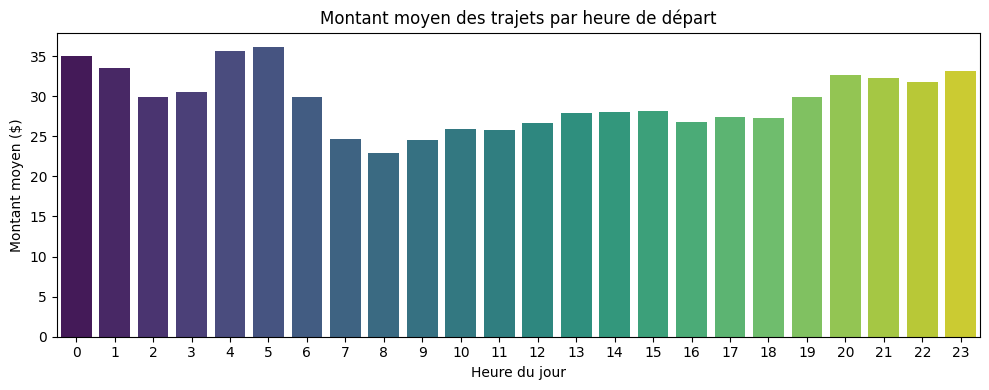

In [ ]:
plt.figure(figsize=(10,4))

sns.barplot(
    x="start_hour",
    y="Trip Total",
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette="viridis"
)

plt.title("Montant moyen des trajets par heure de départ")
plt.xlabel("Heure du jour")
plt.ylabel("Montant moyen ($)")
plt.show()


On observe des différences nettes du montant moyen selon l’heure de départ. Les trajets sont nettement plus chers la nuit (0h–5h) et en fin de soirée (20h–23h), tandis que les montants sont plus bas en matinée et en milieu de journée. Cette variation marquée confirme que l’heure a un impact réel sur le prix des courses. Par conséquent, l’encodage cyclique hour_sin et hour_cos sera pertinent et utile pour le modèle, car il permet de capturer proprement cette dynamique horaire.

In [5]:
df["hour_sin"] = np.sin(2 * np.pi * df["start_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["start_hour"] / 24)
df["is_night"] = df["start_hour"].isin([22,23,0,1,2,3,4,5,6]).astype(int)

**Jours de la semaine :**

C:\Users\jbche\AppData\Local\Temp\ipykernel_24132\3081923719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


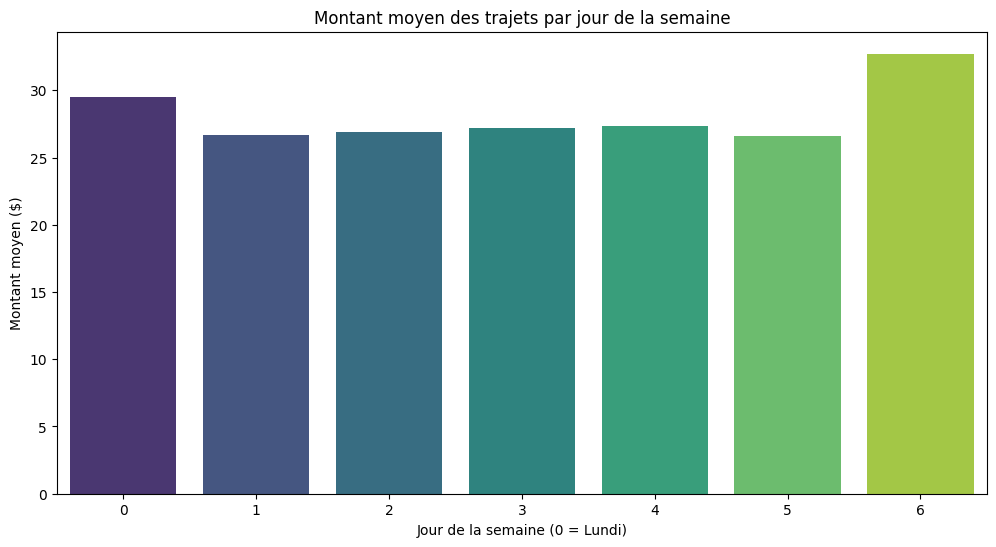

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="start_weekday",
    y="Trip Total",
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette="viridis"  
)

plt.title("Montant moyen des trajets par jour de la semaine")
plt.xlabel("Jour de la semaine (0 = Lundi)")
plt.ylabel("Montant moyen ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()


Les montants moyens varient selon le jour de la semaine. Le lundi (0) et surtout le dimanche (6) affichent les montants les plus élevés, tandis que les mardi–vendredi restent dans une plage plus basse et relativement stable. Le dimanche se démarque nettement comme le jour le plus cher. Cette variation montre que le jour de la semaine influence le prix des trajets, ce qui en fait une variable pertinente à intégrer dans ton modèle de prédiction.

**Week end vs Semaine**

C:\Users\jbche\AppData\Local\Temp\ipykernel_24132\2003036255.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


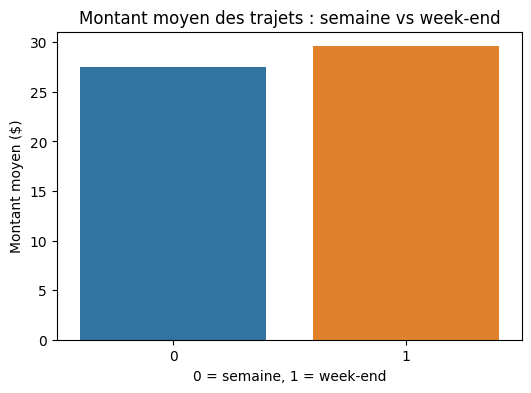

In [10]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="is_weekend",
    y="Trip Total",
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette={"0": "#1f77b4", "1": "#ff7f0e"}
)


plt.title("Montant moyen des trajets : semaine vs week-end")
plt.xlabel("0 = semaine, 1 = week-end")
plt.ylabel("Montant moyen ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()


Les trajets effectués le week-end sont en moyenne légèrement plus chers que ceux de la semaine. Cette différence, bien que modérée, indique que le week-end influence le montant des courses, ce qui en fait une variable pertinente à intégrer dans le modèle de prédiction.

**Heatmap Jour x Heure :**

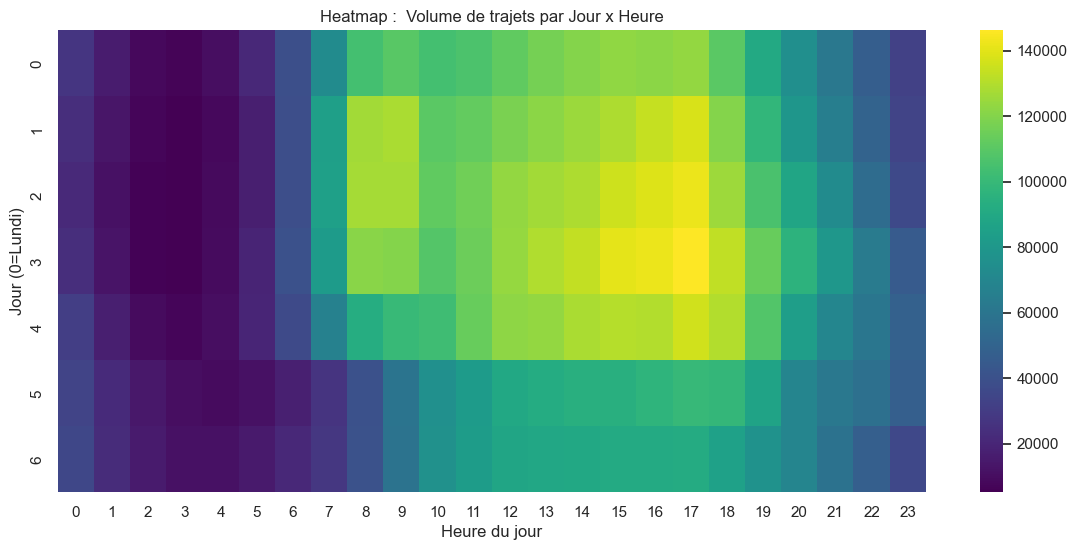

In [13]:
pivot_jour_heure = df.pivot_table(
    index="start_weekday",
    columns="start_hour",
    values="Trip ID",
    aggfunc="count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_jour_heure, cmap="viridis")
plt.title("Heatmap :  Volume de trajets par Jour x Heure")
plt.xlabel("Heure du jour")
plt.ylabel("Jour (0=Lundi)")
plt.show()

- Le volume de trajets présente une structure temporelle très marquée : l’activité est faible entre minuit et 5h, augmente rapidement à partir de 7h et atteint son maximum en fin de matinée et en fin d’après-midi.
- La même dynamique se répète du lundi au vendredi, tandis que les week-ends montrent une baisse globale de l’activité mais conservent les mêmes tendances horaires.
- Ce schéma confirme l’importance des effets horaires et suggère que les variations de prix ou de durée peuvent être influencées par la période de la journée plutôt que par un « rush hour » strict.


**Heatmap Mois x Heure :**

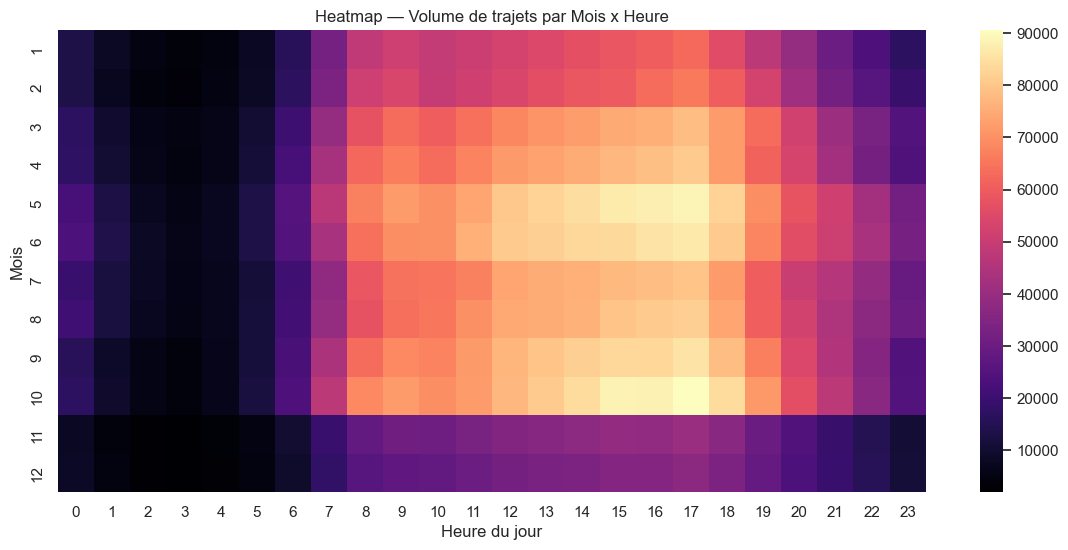

In [14]:
pivot_mois_heure = df.pivot_table(
    index="start_month",
    columns="start_hour",
    values="Trip ID",
    aggfunc="count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_mois_heure, cmap="magma")
plt.title("Heatmap — Volume de trajets par Mois x Heure")
plt.xlabel("Heure du jour")
plt.ylabel("Mois")
plt.show()

même conclusion que ci-dessus avec un apperçu mensuelle

**Durée par période :**

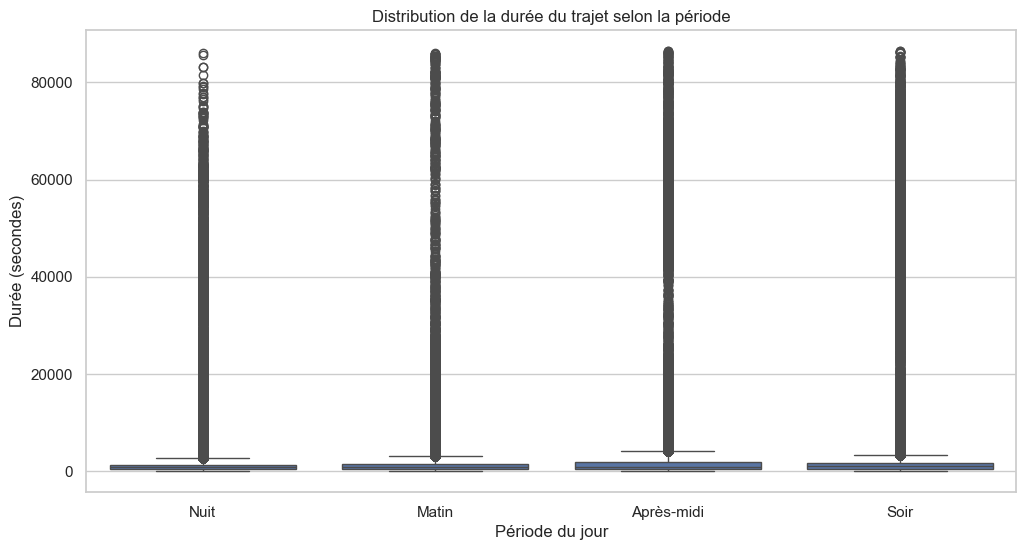

In [15]:
plt.figure()
sns.boxplot(x="period_of_day", y="Trip Seconds", data=df)
plt.title("Distribution de la durée du trajet selon la période")
plt.xlabel("Période du jour")
plt.ylabel("Durée (secondes)")
plt.show()

C:\Users\jbche\AppData\Local\Temp\ipykernel_24132\660957692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


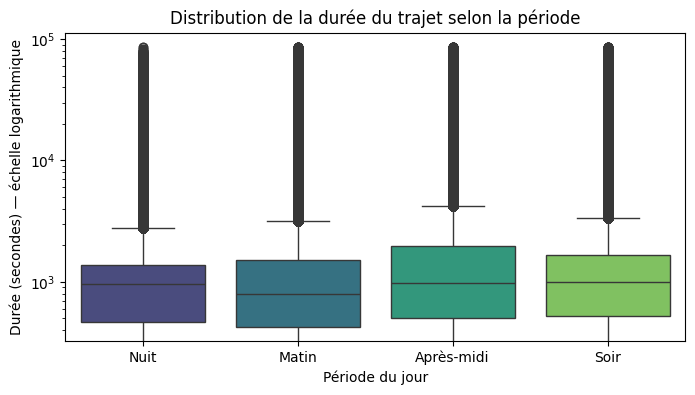

In [14]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x="period_of_day",
    y="Trip Seconds",
    data=df,
    palette="viridis"   
)

plt.title("Distribution de la durée du trajet selon la période")
plt.xlabel("Période du jour")
plt.ylabel("Durée (secondes) échelle logarithmique")
plt.yscale("log")

plt.show()


- La distribution des durées est très asymétrique, avec de nombreux trajets anormalement longs qui tirent les boxplots vers le haut.
- Les différences entre périodes (nuit, matin, après-midi, soir) sont faibles une fois les valeurs extrêmes prises en compte.
- Ce résultat suggère qu’une variable “période de la journée” n’apporte pas d’information significative pour modéliser la durée ou le prix, et que l’encodage cyclique (sin/cos) de l’heure est plus approprié.


**Distance moyenne par heure :**

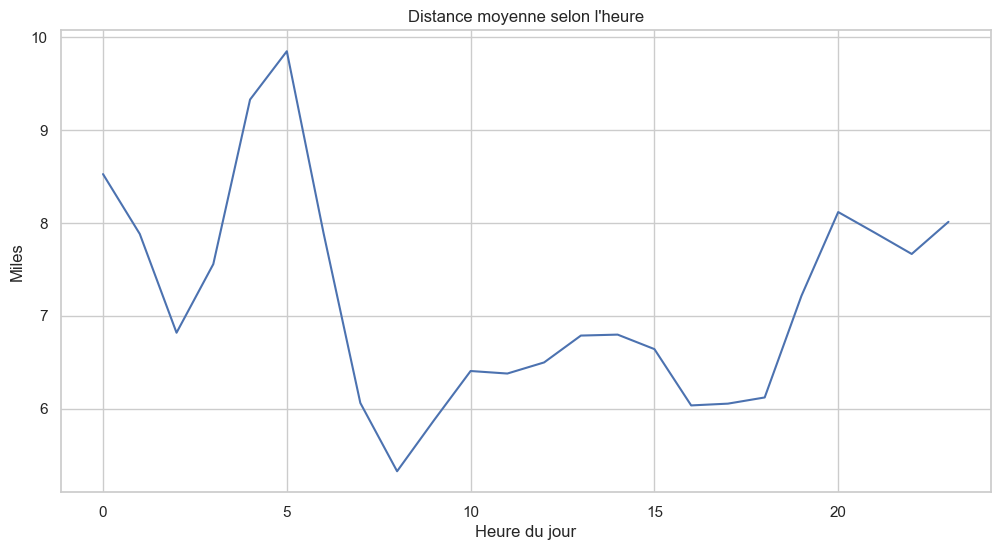

In [17]:
dist_heure = df.groupby("start_hour")["Trip Miles"].mean()

plt.figure()
dist_heure.plot()
plt.title("Distance moyenne selon l'heure")
plt.xlabel("Heure du jour")
plt.ylabel("Miles")
plt.show()

- La distance moyenne varie selon l’heure, avec des trajets plus longs entre 4h et 6h du matin, probablement liés à des déplacements vers l’aéroport ou des zones éloignées.
- En journée, la distance moyenne diminue puis reste relativement stable entre 6 et 18h, ce qui correspond à des trajets plus courts typiques des déplacements urbains.
- En soirée, la distance remonte légèrement, ce qui suggère des trajets plus longs liés aux sorties ou aux déplacements hors centre-ville.
- Ces variations horaires indiquent que l’heure contient de l’information pertinente pour la distance et donc pour le prix, ce qui justifie l’encodage cyclique (sin/cos) et la variable binaire nuit/jour.

**Saisonnalité ?**

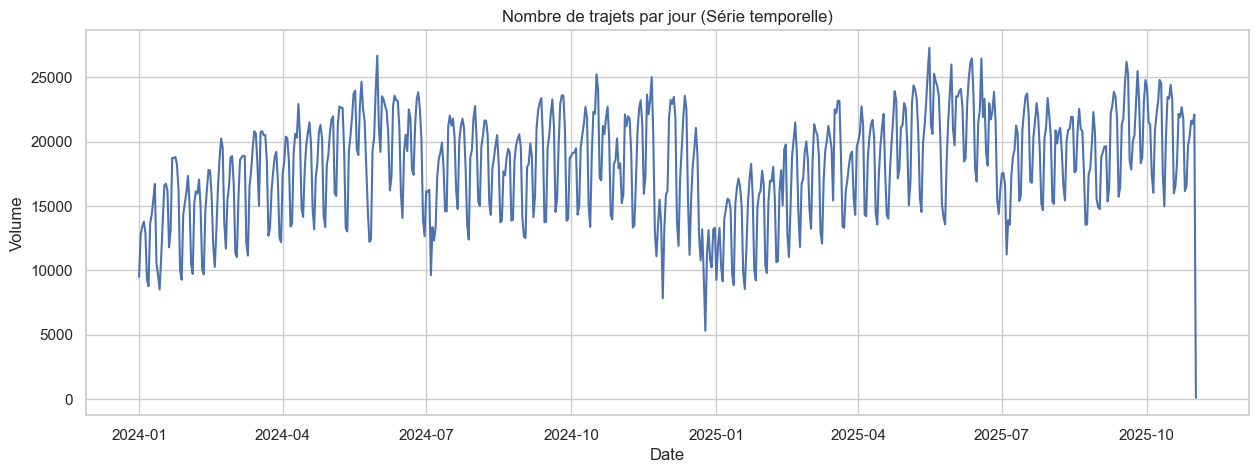

In [19]:
df_daily = df.groupby("start_date").size()

plt.figure(figsize=(15, 5))
df_daily.plot()
plt.title("Nombre de trajets par jour (Série temporelle)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

- Le volume quotidien des trajets présente une forte saisonnalité hebdomadaire, visible à travers les oscillations régulières correspondant aux cycles semaine/week-end.
- On observe également une tendance globale légèrement croissante au fil de l’année, interrompue par quelques chutes ponctuelles probablement dues à des jours fériés, des conditions météo extrêmes ou des problèmes de collecte de données.
- La baisse nette en fin d’année et les valeurs quasi nulles sur certaines dates indiquent des anomalies ou des jours incomplets dans le dataset.
- Ces variations influencent le volume global mais ne sont pas directement nécessaires pour prédire le prix d’un trajet individuel, ce qui signifie qu’aucune variable dérivée basée sur la date complète n’est requise pour le modèle.
- Cette série temporelle sert uniquement à vérifier qu’il n’y a rien d’anormal dans les données (jours manquants, chutes de volume, incohérences). 
- Elle ne fournit pas d’information directement utile pour prédire le prix d’un trajet individuel, donc aucune variable dérivée n’est créée à partir de cette analyse.

# Analyse univariée des variables numériques


**Statistiques Descriptives**

In [20]:
num_vars = [
    "Trip Seconds",
    "Trip Miles",
    "Fare",
    "Tips",
    "Tolls",
    "Extras",
    "Trip Total"
]

df[num_vars].describe()

,Trip Seconds,Trip Miles,Fare,Tips,Tolls,Extras,Trip Total
count,1.220411e+07,1.220411e+07,1.220411e+07,1.220411e+07,1.220411e+07,1.220411e+07,1.220411e+07
mean,1.250068e+03,6.696456e+00,2.276793e+01,2.839441e+00,3.122512e-02,2.086903e+00,2.795684e+01
std,1.629722e+03,7.647498e+00,3.197665e+01,4.271408e+00,4.105404e+00,9.168763e+00,3.658497e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.800000e+02,1.070000e+00,8.500000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.025000e+01
50%,9.260000e+02,3.220000e+00,1.565000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.860000e+01
75%,1.695000e+03,1.180000e+01,3.425000e+01,4.000000e+00,0.000000e+00,2.000000e+00,4.231000e+01
max,8.640000e+04,3.397800e+03,9.999750e+03,4.000000e+02,5.550000e+03,5.559500e+03,9.999750e+03


In [24]:
cond_sec = df["Trip Seconds"] < 30
cond_miles = df["Trip Miles"] < 0.1
cond_fare = df["Fare"] < 3


n_sec = cond_sec.sum()
n_miles = cond_miles.sum()
n_fare = cond_fare.sum()

print(f"Durée < 30 sec : {n_sec}")
print(f"Distance < 0.1 mile : {n_miles}")
print(f"Fare < 3$ : {n_fare}")


Durée < 30 sec : 627619
Distance < 0.1 mile : 1227724
Fare < 3$ : 102129


In [25]:
# Nettoyage minimal cohérent avec les données taxi

# 1. Durée minimale réaliste : >= 30 sec
df = df[df["Trip Seconds"] >= 30]

# 2. Distance minimale réaliste : >= 0.1 mile
df = df[df["Trip Miles"] >= 0.1]

# 3. Prix minimal réaliste (tarif d'ouverture Chicago) : >= 3$
df = df[df["Fare"] >= 3]

# 4. Distance maximale réaliste : <= 50 miles (au-delà = erreurs GPS)
df = df[df["Trip Miles"] <= 50]

# 5. Nettoyage distance = 0 & durée > 120 sec déjà fait, mais au cas où :
df = df[~((df["Trip Miles"] == 0) & (df["Trip Seconds"] > 120))]


- Nous appliquons une série de seuils réalistes afin de garantir la cohérence des trajets conservés pour la modélisation.
- Une durée minimale de 30 secondes est imposée, car un trajet réel ne peut pas être instantané.
- Une distance minimale de 0.1 mile (~160 m) est retenue pour éviter les erreurs GPS ou les enregistrements partiels.
- Le tarif Fare doit être au moins égal à 3 dollars, correspondant au tarif d’ouverture du compteur à Chicago.
- Les distances supérieures à 50 miles sont supprimées : ces valeurs sont dues à des erreurs de géolocalisation, car un trajet taxi urbain ne dépasse jamais cette distance.
- Après nettoyage, le dataset conserve uniquement des observations plausibles tout en maintenant un volume important pour la modélisation.


In [23]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df[num_vars].describe()

,Trip Seconds,Trip Miles,Fare,Tips,Tolls,Extras,Trip Total
count,10942196.000,10942196.000,10942196.000,10942196.000,10942196.000,10942196.000,10942196.000
mean,1329.859,7.411,22.743,2.875,0.031,2.024,27.915
std,1524.221,6.960,17.226,4.187,3.442,8.087,24.210
min,30.000,0.100,3.000,0.000,0.000,0.000,3.000
25%,551.000,1.460,8.750,0.000,0.000,0.000,10.750
50%,1020.000,4.440,16.630,0.500,0.000,0.000,19.250
75%,1775.000,12.550,34.500,4.000,0.000,3.000,42.750
max,86396.000,50.000,6950.690,400.000,4444.440,5559.500,8940.880


- Nous identifions deux types d’anomalies  :
  - des trajets ayant une durée égale à 0 seconde, ce qui est impossible en pratique 
  - des trajets ayant une distance nulle mais une durée supérieure à 2 minutes, généralement causés par des erreurs de mesure GPS ou des enregistrements incorrects du compteur.


- Nous appliquons ensuite des seuils minimaux réalistes pour garantir la cohérence économique des trajets.
- Un trajet réel dure rarement moins de 30 secondes, parcourt au moins 0.1 mile (≈160 m) et implique un tarif d’ouverture d’au moins 3 dollars.
- Ces règles permettent de retirer les enregistrements aberrants ou issus d’erreurs de compteur, tout en conservant des données plausibles pour la modélisation.


**Percentiles :**

In [24]:
percentiles = [0.01, 0.05, 0.95, 0.99]

outlier_table = df[num_vars].quantile(percentiles).T
outlier_table.columns = [f"{int(p*100)}%" for p in percentiles]
display(outlier_table)

,1%,5%,95%,99%
Trip Seconds,133.000,256.000,3300.000,4620.000
Trip Miles,0.280,0.600,18.550,27.150
Fare,4.250,5.500,50.370,71.500
Tips,0.000,0.000,11.000,15.750
Tolls,0.000,0.000,0.000,0.000
Extras,0.000,0.000,6.000,30.000
Trip Total,4.500,6.250,66.600,97.000


- L’analyse des percentiles montre que les valeurs extrêmes (1%–99%) sont cohérentes avec des trajets taxi réels.
- Les durées supérieures à 1h, les distances supérieures à 25 miles ou les prix supérieurs à 70 dollars correspondent à des courses longues mais plausibles.
- L’objectif ici est surtout d’identifier des anomalies éventuelles ; aucune coupure automatique n’est nécessaire.
- Les seuils minimaux retenus (durée ≥ 30 sec, distance ≥ 0.1 mile, fare ≥ 3 dollars) restent cohérents avec la distribution observée.


**Histogrammes :**

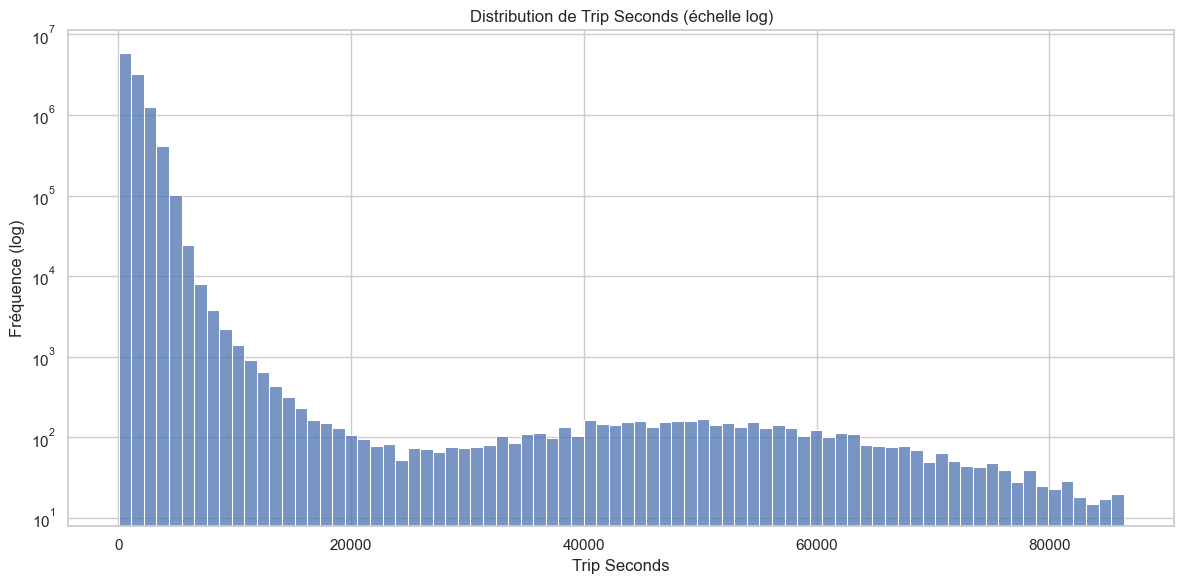

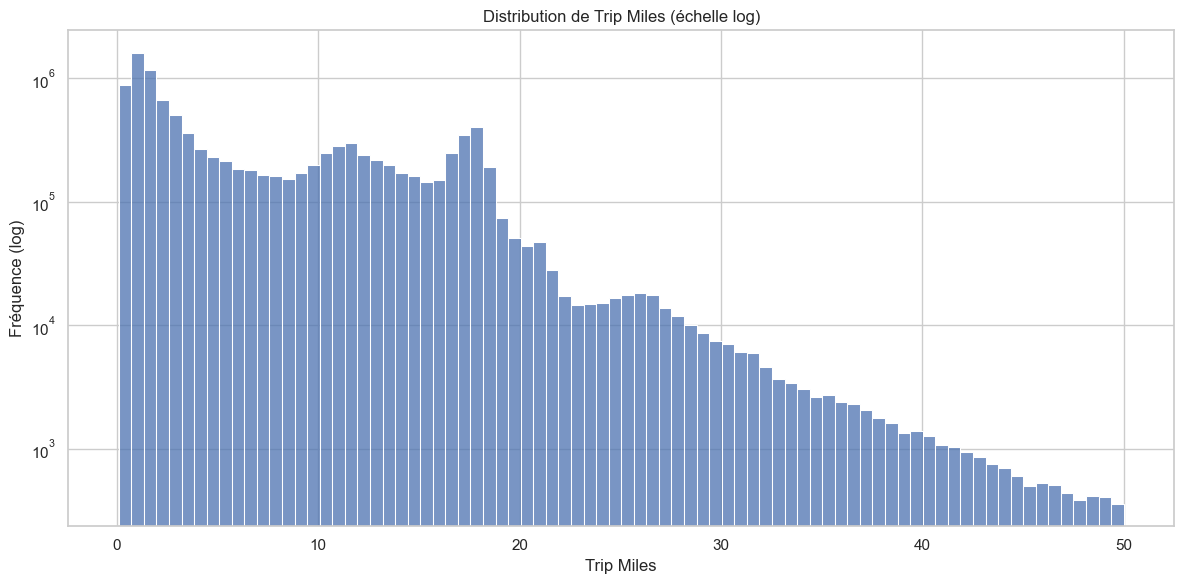

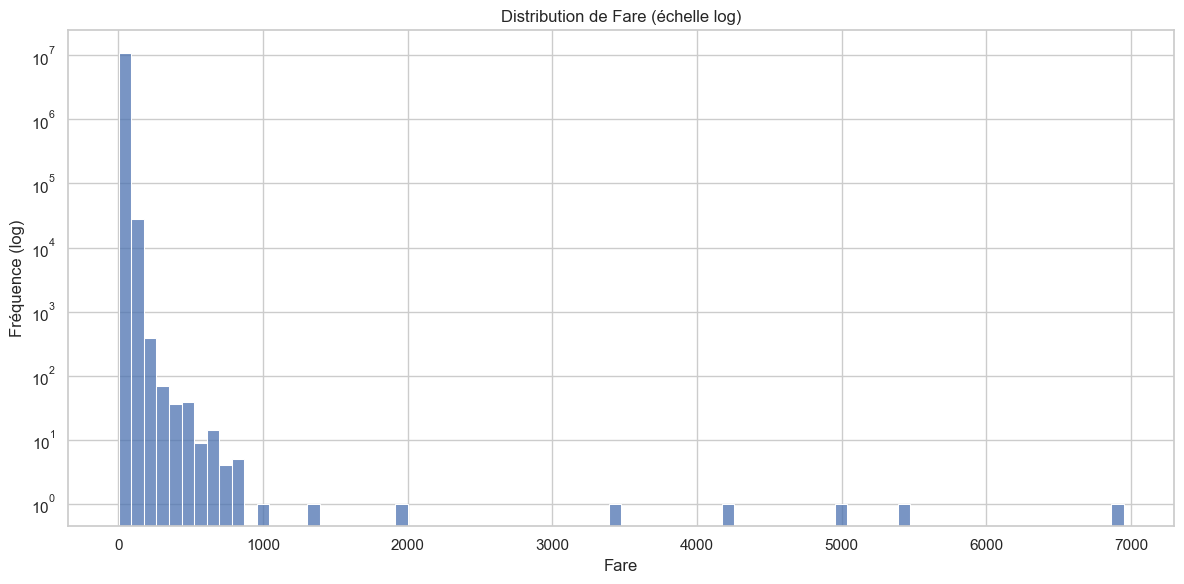

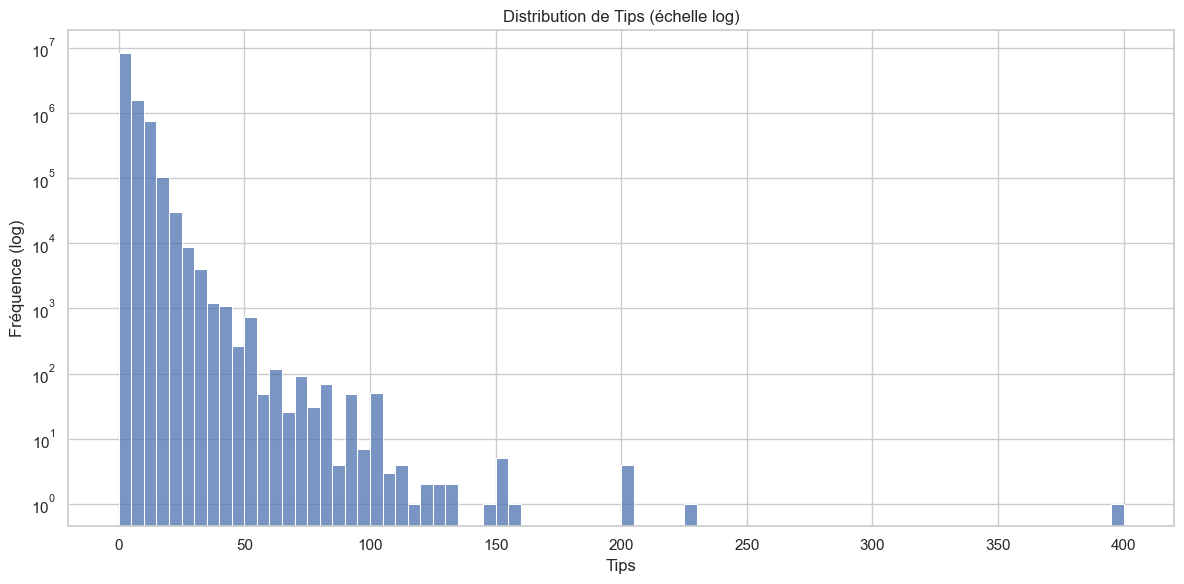

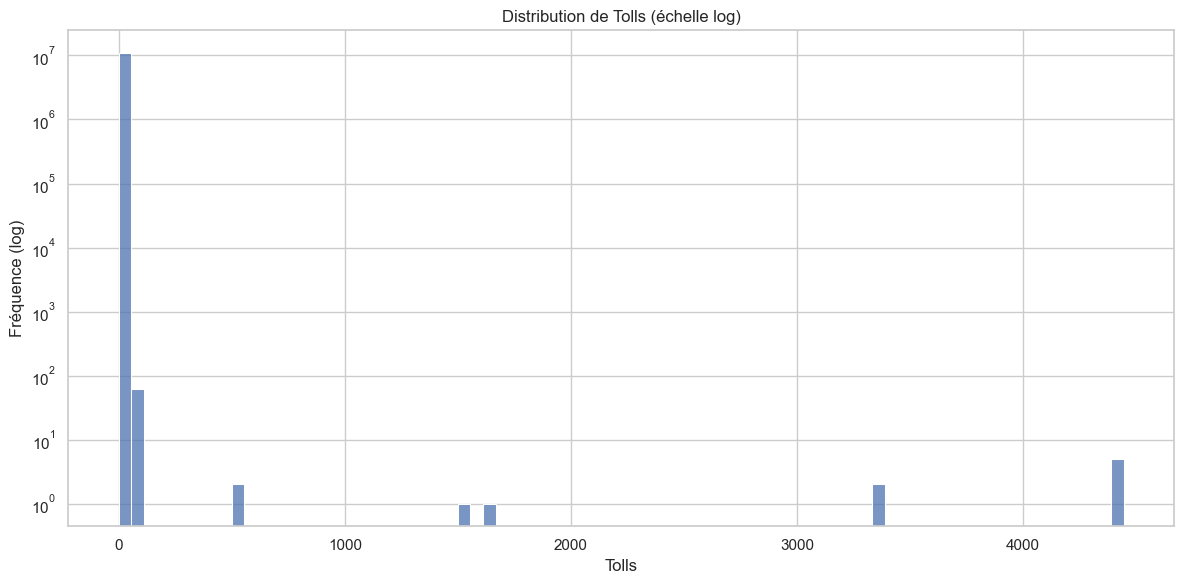

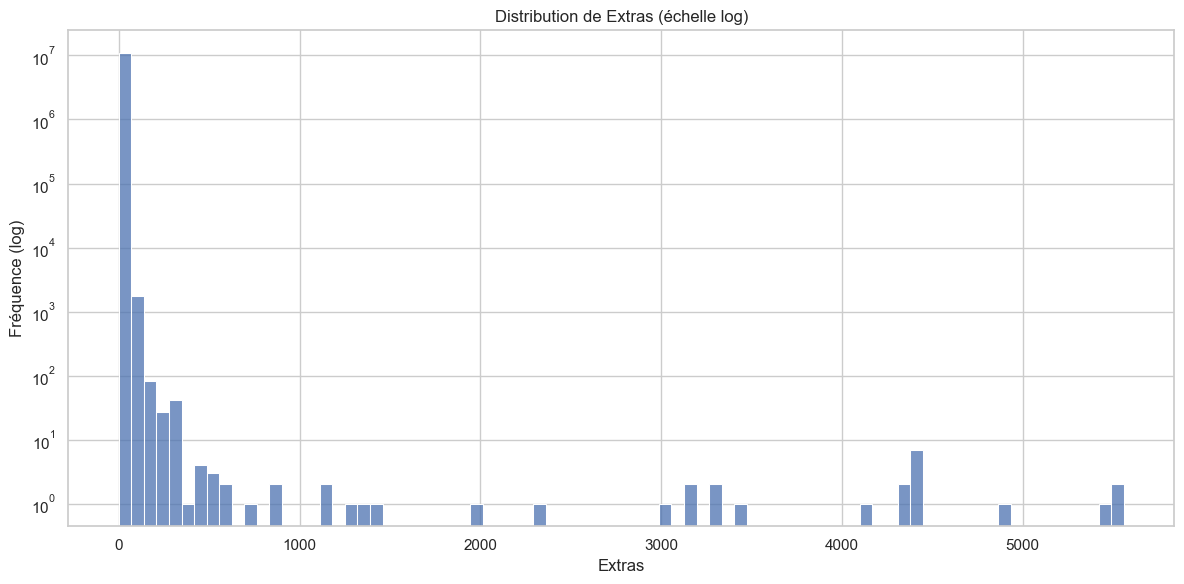

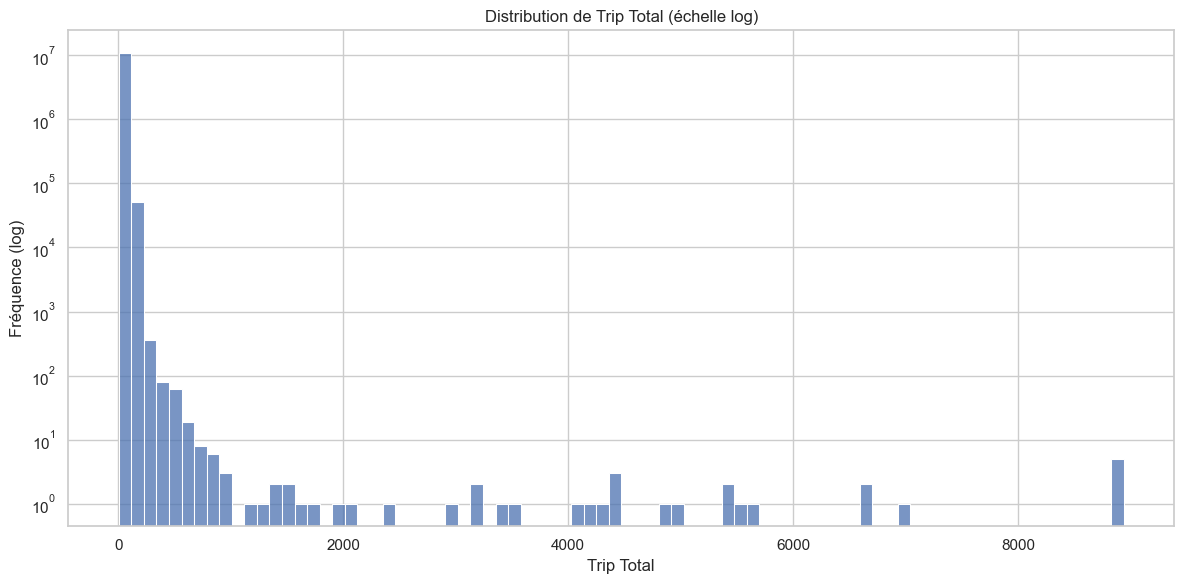

In [25]:
for col in num_vars:
    plt.figure()
    sns.histplot(df[col], bins=80, kde=False)
    plt.yscale("log")          # échelle logarithmique
    plt.title(f"Distribution de {col} (échelle log)")
    plt.xlabel(col)
    plt.ylabel("Fréquence (log)")
    plt.tight_layout()
    plt.show()


In [26]:
# distances
df = df[df["Trip Miles"] <= 50]

# fare et total
df = df[df["Fare"] <= 200]
df = df[df["Trip Total"] <= 300]

# tips / extras / tolls
df = df[df["Tips"] <= 100]
df = df[df["Extras"] <= 50]
df = df[df["Tolls"] <= 100]


- Les distributions en échelle logarithmique révèlent la présence d’outliers extrêmes (valeurs allant jusqu’à plusieurs milliers de dollars).
- Ces valeurs sont impossibles dans le contexte des taxis de Chicago et proviennent d’erreurs de compteur, de GPS ou d’enregistrements corrompus.
- Pour garantir la stabilité du modèle et conserver uniquement des données réalistes, nous appliquons des seuils maximaux : 
  - Fare ≤ 200 $ 
  - Trip Total ≤ 300 $ 
  - Tips ≤ 100 $ 
  - Extras ≤ 50 $ 
  - Tolls ≤ 100 $ 
  - Trip Miles ≤ 50 miles.
- Après ce nettoyage, les distributions deviennent cohérentes avec l’activité réelle des taxis et exploitables pour la modélisation.


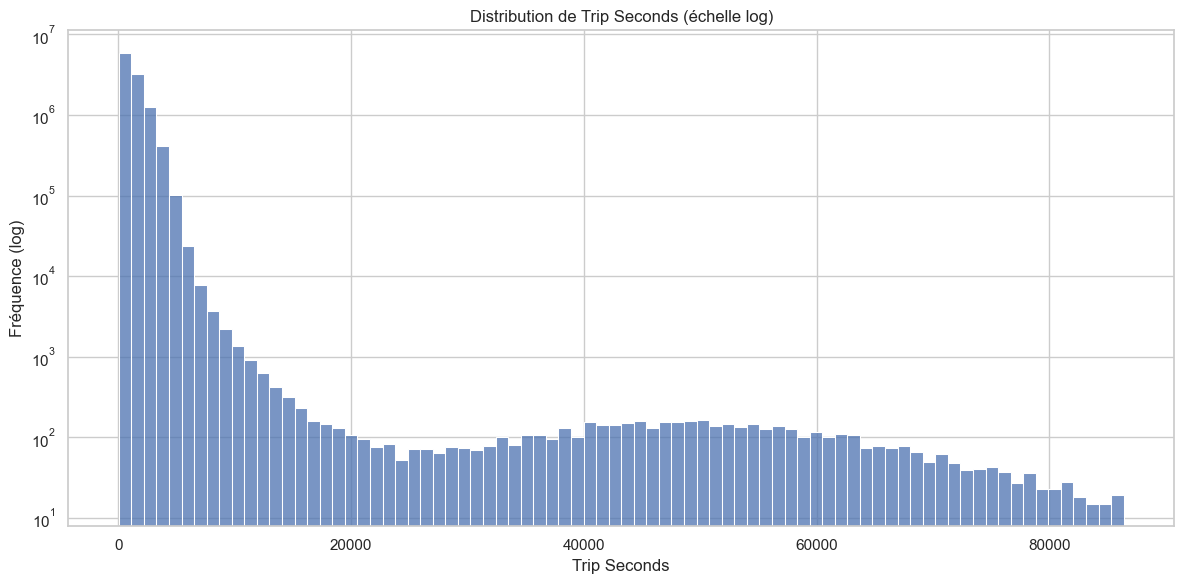

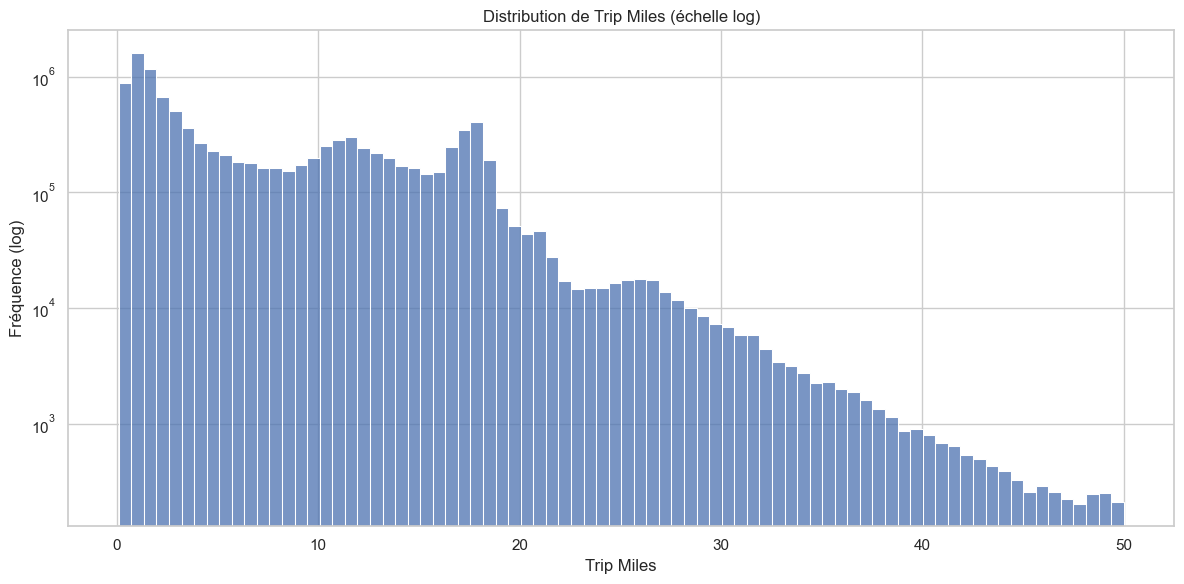

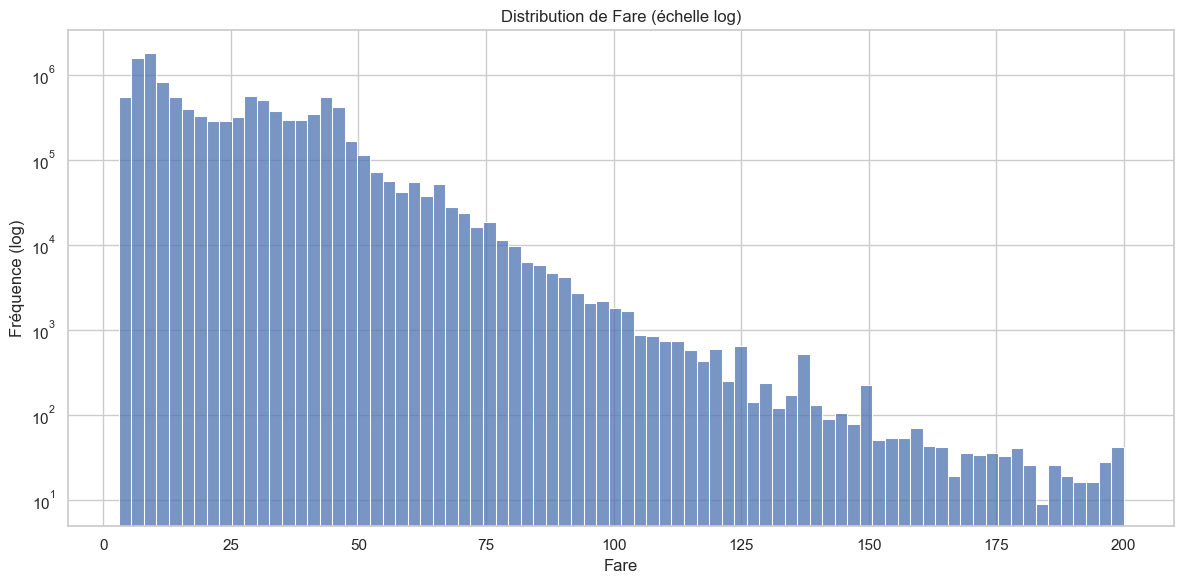

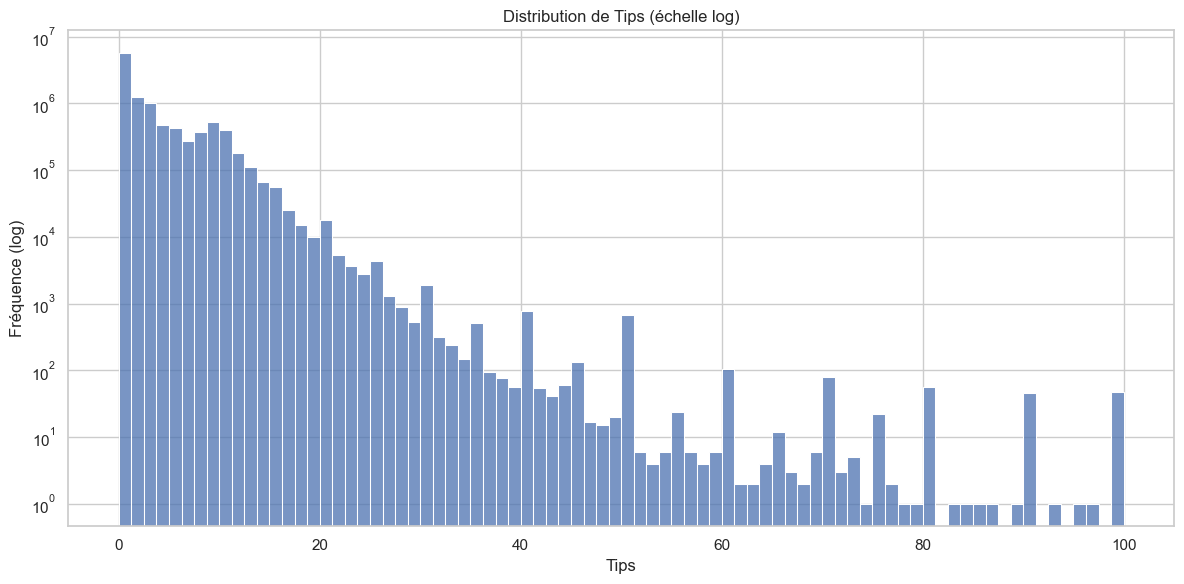

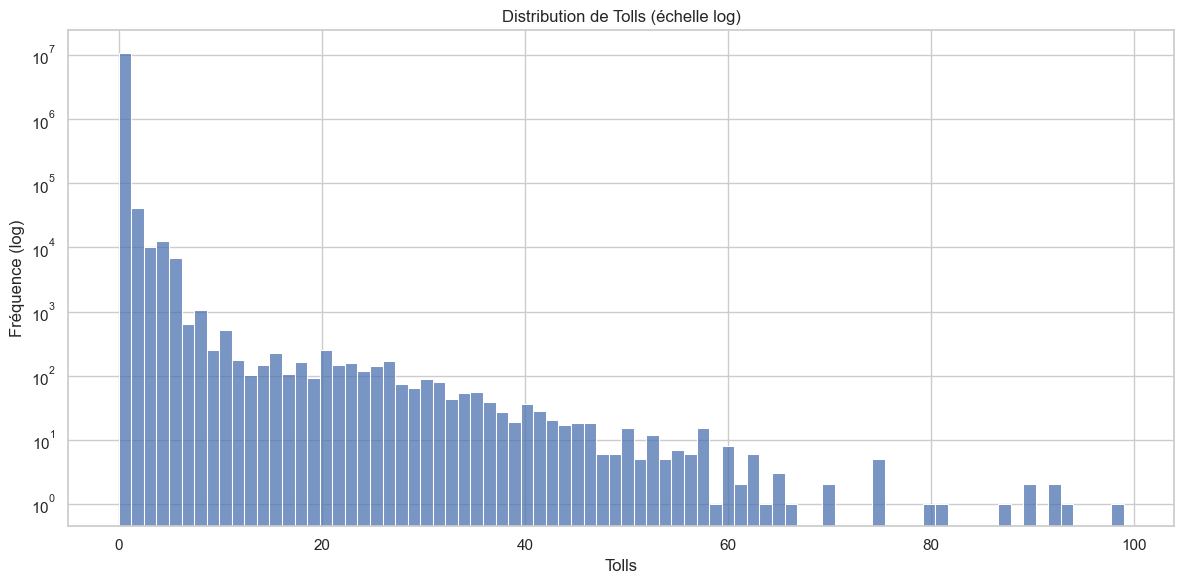

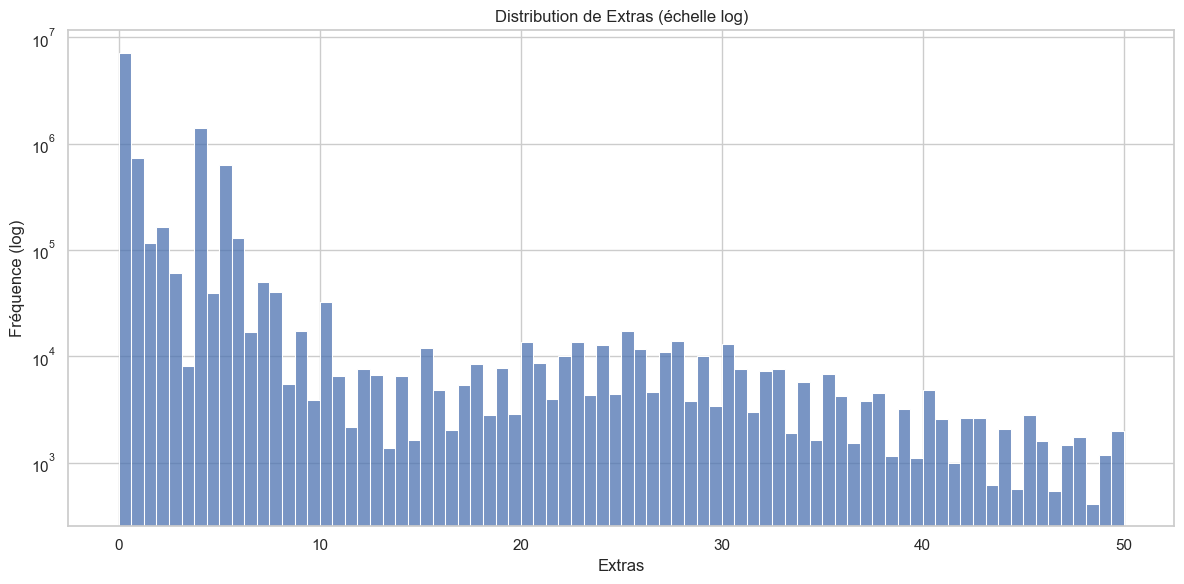

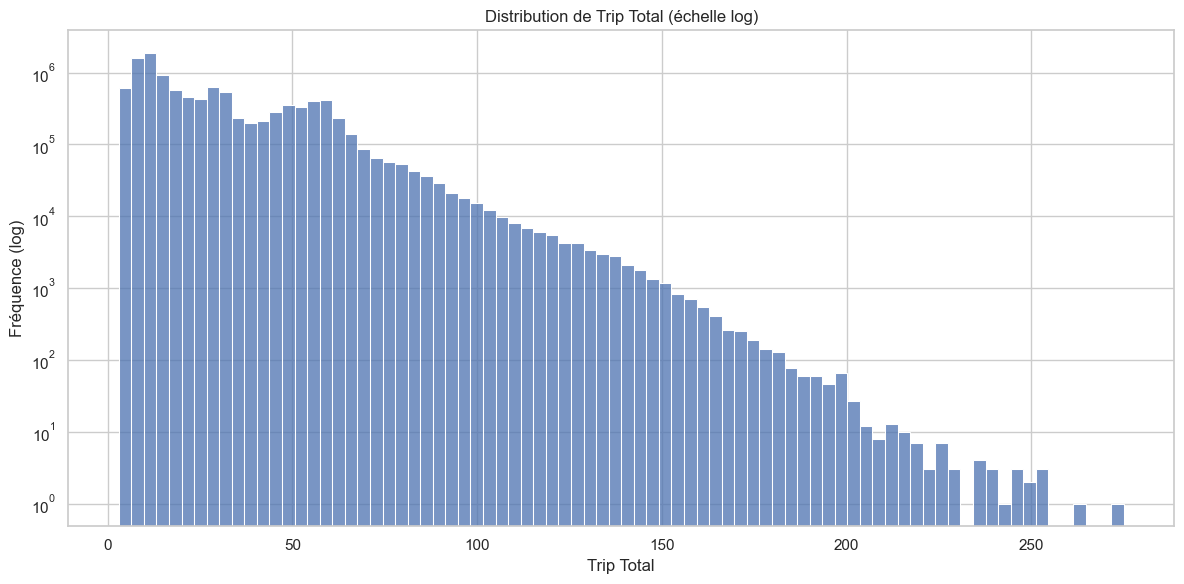

In [27]:
for col in num_vars:
    plt.figure()
    sns.histplot(df[col], bins=80, kde=False)
    plt.yscale("log")          
    plt.title(f"Distribution de {col} (échelle log)")
    plt.xlabel(col)
    plt.ylabel("Fréquence (log)")
    plt.tight_layout()
    plt.show()


# Analyse univariée des variables catégorielles

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10927821 entries, 0 to 12204110
Data columns (total 25 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Unnamed: 0              int64         
 1   Trip ID                 object        
 2   Taxi ID                 object        
 3   Trip Start Timestamp    datetime64[ns]
 4   Trip End Timestamp      datetime64[ns]
 5   Trip Seconds            float64       
 6   Trip Miles              float64       
 7   Pickup Community Area   float64       
 8   Dropoff Community Area  float64       
 9   Fare                    float64       
 10  Tips                    float64       
 11  Tolls                   float64       
 12  Extras                  float64       
 13  Trip Total              float64       
 14  Payment Type            object        
 15  Company                 object        
 16  start_hour              int32         
 17  start_weekday           int32         
 18  start

**Fréquences de Payment Type :**

In [29]:
payment_counts = df["Payment Type"].value_counts()
print("=== Payment Type — fréquences ===")
print(payment_counts)

=== Payment Type — fréquences ===
Payment Type
Credit Card    4173035
Cash           2556340
Mobile         2324719
Prcard         1415987
Unknown         434141
No Charge        19411
Dispute           4188
Name: count, dtype: int64


In [27]:
# 1. Suppression des types incohérents
df = df[~df["Payment Type"].isin(["No Charge", "Dispute"])]

# 2. Frequency encoding
freq = df["Payment Type"].value_counts(normalize=True)
df["payment_freq"] = df["Payment Type"].map(freq)


- La variable Payment Type présente plusieurs catégories : carte, cash, mobile, prcard, ainsi que quelques classes mineures telles que "No Charge" et "Dispute".
- Les catégories "No Charge" et "Dispute" ne correspondent pas à un paiement réel et sont supprimées du dataset afin d'éviter de fausser la modélisation du prix.
- Pour les catégories restantes, un frequency encoding est appliqué : chaque type de paiement est remplacé par sa fréquence d'apparition dans le dataset.
- Ce choix permet de représenter efficacement cette variable sans explosion de dimensions et sans imposer d'ordre arbitraire, ce qui est idéal pour les modèles d’arbres (XGBoost, RandomForest, CatBoost).


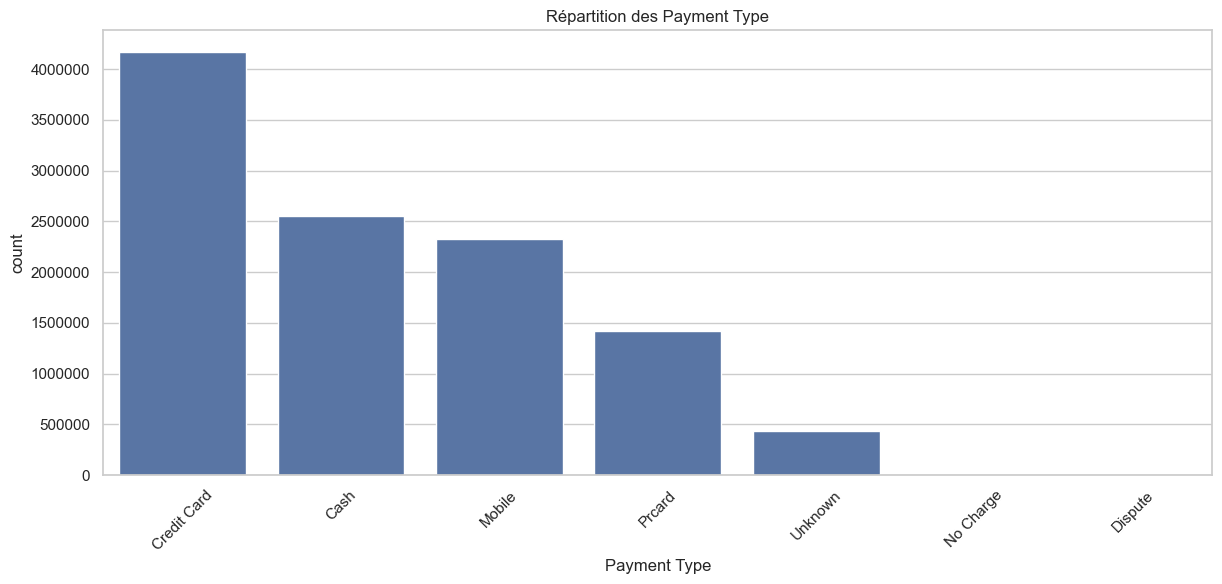

In [31]:
plt.figure()
sns.countplot(data=df, x="Payment Type", order=payment_counts.index)
plt.title("Répartition des Payment Type")
plt.xticks(rotation=45)
plt.tight_layout()

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
plt.show()

**Carte vs Cash dans le temps (mensuel)**

<Figure size 640x480 with 0 Axes>

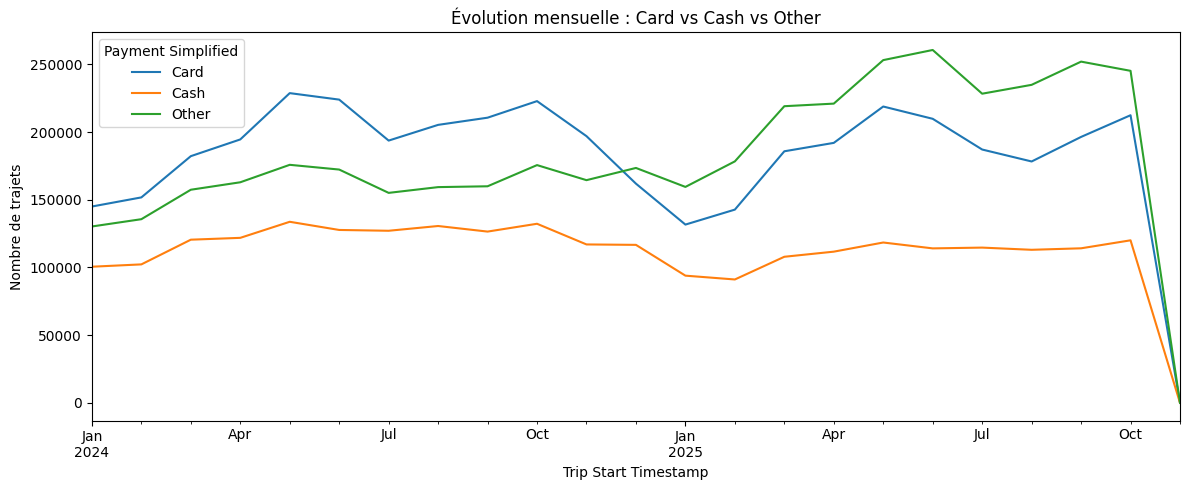

In [28]:
df["Payment Simplified"] = df["Payment Type"].replace({
    "Credit Card": "Card",
    "Cash": "Cash"
}).where(df["Payment Type"].isin(["Credit Card", "Cash"]), "Other")

monthly_pay = df.groupby([
    df["Trip Start Timestamp"].dt.to_period("M"),
    "Payment Simplified"
]).size().unstack().fillna(0)

monthly_pay.index = monthly_pay.index.to_timestamp()

plt.figure()
monthly_pay.plot(figsize=(12, 5))
plt.title("Évolution mensuelle : Card vs Cash vs Other")
plt.ylabel("Nombre de trajets")
plt.tight_layout()
plt.show()

- Les paiements par carte (« Card ») sont largement dominants tout au long de la période.  
  Ils représentent en moyenne entre 180 000 et 230 000 trajets par mois.

- Les paiements « Other » (principalement Mobile, Prcard, etc.) sont le second mode le plus utilisé,
  avec un volume légèrement inférieur à celui des paiements par carte, mais globalement stable.

- Les paiements en espèces (« Cash ») sont nettement moins fréquents, autour de 100 000 à 130 000 trajets par mois.
  Leur utilisation reste plutôt stable dans le temps, avec une légère baisse en hiver.

- On observe globalement une saisonnalité : hausse au printemps/été, baisse en fin d'année.
  Cela semble refléter une saisonnalité générale des trajets plutôt qu’un changement de préférence de paiement.

- Le dernier point proche de 0 correspond à une coupure du dataset (mois incomplet), et ne doit pas être interprété.


### Changement de plan : 

La variable “Payment freq ne doit pas être utilisée pour prédire le montant de la course, car elle est décidée après le trajet. Le mode de paiement dépend du prix (les trajets chers sont plus souvent payés en carte), donc l’utiliser dans un modèle reviendrait à donner au modèle une information qu’il ne devrait pas connaître avant la prédiction. C’est un cas typique de data leakage : la variable est informative, mais illégitime. Elle doit donc être exclue des features du modèle.

**Company :**

=== Top 20 compagnies ===


Company
Flash Cab                            2547656
Taxi Affiliation Services            1666006
Taxicab Insurance Agency Llc         1412847
Sun Taxi                             1322384
City Service                         1190644
Chicago Independents                  743991
5 Star Taxi                           600721
Blue Ribbon Taxi Association          517934
Globe Taxi                            415052
Transit Administrative Center Inc     337634
Tac - Yellow Cab Association          323105
Medallion Leasin                      309044
Choice Taxi Association Inc           159791
Taxicab Insurance Agency, LLC         132629
Choice Taxi Association               112480
Chicago City Taxi Association         109733
Wolley Taxi                            41016
Top Cab                                36344
U Taxicab                              30050
Koam Taxi Association                  29853
Name: count, dtype: int64

C:\Users\jbche\AppData\Local\Temp\ipykernel_24132\2367251653.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


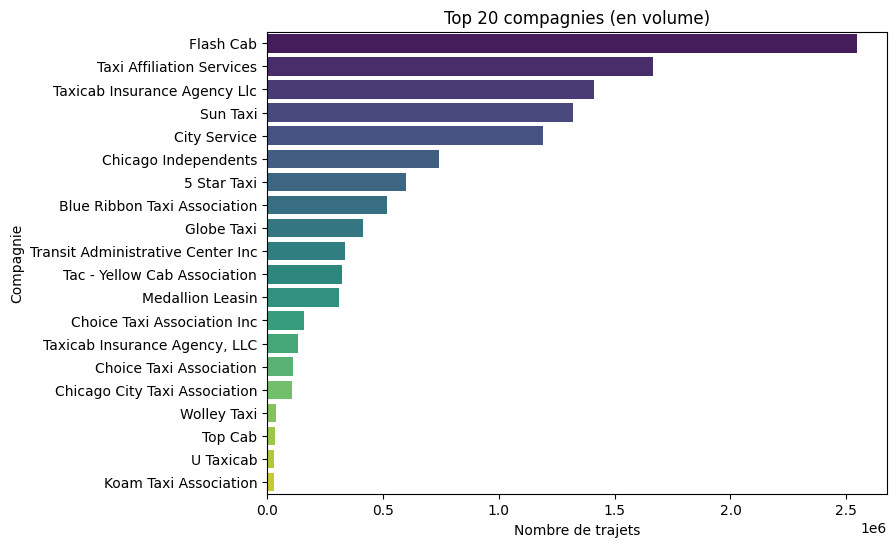

In [15]:
company_counts = df["Company"].value_counts()

print("=== Top 20 compagnies ===")
display(company_counts.head(20))

plt.figure(figsize=(8,6))

sns.barplot(
    x=company_counts.head(20).values,
    y=company_counts.head(20).index,
    palette="viridis"   
)

plt.title("Top 20 compagnies (en volume)")
plt.xlabel("Nombre de trajets")
plt.ylabel("Compagnie")
plt.show()


In [29]:

company_freq = df["Company"].value_counts(normalize=True)


threshold = 0.001
small_companies = company_freq[company_freq < threshold].index

print(f"Nombre de petites compagnies regroupées : {len(small_companies)}")


df["Company_clean"] = df["Company"].replace(small_companies, "Other")


company_clean_freq = df["Company_clean"].value_counts(normalize=True)

print("=== Top 10 Company_clean ===")
print(company_clean_freq.head(10))


df["company_freq"] = df["Company_clean"].map(company_clean_freq)

df[["Company_clean", "company_freq"]].head()


Nombre de petites compagnies regroupées : 21
=== Top 10 Company_clean ===
Company_clean
Flash Cab                       0.213837
Taxi Affiliation Services       0.122086
Taxicab Insurance Agency Llc    0.119850
Sun Taxi                        0.114634
City Service                    0.102855
Chicago Independents            0.063450
5 Star Taxi                     0.049991
Blue Ribbon Taxi Association    0.044971
Globe Taxi                      0.036164
Medallion Leasin                0.026383
Name: proportion, dtype: float64


,Company_clean,company_freq
0,Taxicab Insurance Agency Llc,0.119850
1,Choice Taxi Association Inc,0.013081
2,5 Star Taxi,0.049991
3,Sun Taxi,0.114634
4,Chicago City Taxi Association,0.008777


- La variable Company contient un grand nombre de compagnies avec des fréquences très faibles.
- Pour réduire le bruit et éviter l'explosion dimensionnelle, toutes les compagnies représentant moins de 0.1 % des trajets sont regroupées dans une catégorie « Other ».
- Ensuite, un frequency encoding est appliqué sur la variable regroupée.
- Le frequency encoding capture l’importance relative des compagnies tout en restant compact et efficace pour des modèles d’arbres comme RandomForest ou XGBoost.

| Niveau du HHI         | Concentration du marché | Interprétation                          |
| --------------------- | ----------------------- | --------------------------------------- |
| **HHI < 0.15**        | Faible                  | Marché très concurrentiel               |
| **0.15 ≤ HHI < 0.25** | Modérée                 | Quelques acteurs plus gros              |
| **HHI ≥ 0.25**        | Forte                   | Marché dominé, risque de quasi-monopole |
| **HHI ≥ 0.50**        | Très forte              | 2–3 acteurs contrôlent presque tout     |


In [35]:
company_share = company_counts / company_counts.sum()
hhi = (company_share**2).sum()
print(f"HHI (Herfindahl-Hirschman Index) : {hhi:.4f}")


top5_share = company_share.head(5).sum()
print(f"Top 5 compagnies — part de marché : {top5_share*100:.2f}%")

HHI (Herfindahl-Hirschman Index) : 0.1107
Top 5 compagnies — part de marché : 67.33%


In [19]:
pickup_counts = df["Pickup Community Area"].value_counts()
dropoff_counts = df["Dropoff Community Area"].value_counts()

print("=== Top 10 Pickup Areas ===")
display(pickup_counts.head(10))

print("=== Top 10 Dropoff Areas ===")
display(dropoff_counts.head(10))

print("=== Bottom 10 Pickup Areas ===")
display(pickup_counts.tail(10))

print("=== Bottom 10 Dropoff Areas ===")
display(dropoff_counts.tail(10))

=== Top 10 Pickup Areas ===


Pickup Community Area
 8.0     2624796
 76.0    2516199
 32.0    1951153
 28.0    1172065
 33.0     440524
 6.0      400542
 56.0     381087
-1.0      339580
 7.0      258529
 3.0      197322
Name: count, dtype: int64

=== Top 10 Dropoff Areas ===


Dropoff Community Area
 8.0     2838208
 32.0    1998746
 28.0    1165129
-1.0     1109602
 76.0     613678
 6.0      523029
 33.0     481900
 7.0      467142
 24.0     281169
 3.0      222471
Name: count, dtype: int64

=== Bottom 10 Pickup Areas ===


Pickup Community Area
65.0    4419
47.0    4372
62.0    3759
9.0     3724
64.0    3310
74.0    3293
57.0    3283
63.0    1946
20.0    1641
18.0    1528
Name: count, dtype: int64

=== Bottom 10 Dropoff Areas ===


Dropoff Community Area
64.0    5480
47.0    4961
20.0    4481
52.0    4468
57.0    4436
62.0    4344
55.0    3560
63.0    3455
18.0    2971
74.0    1958
Name: count, dtype: int64

- Les zones 8, 76, 32 et 28 concentrent la majorité des départs et arrivées. 
  Elles correspondent aux zones les plus actives de Chicago : Downtown, Near North Side, O’Hare Airport et les quartiers centraux.

- La zone 8 est particulièrement dominante : plus de 2.3M pickups et 2.5M dropoffs. 
  Cela reflète clairement la très forte activité dans le centre-ville.

- La zone 76 (probablement O'Hare Airport) représente également une part massive du trafic, avec plus de 2.3M pickups et près de 500k dropoffs.

- La zone 32 (Near North Side) et la zone 28 (Loop) complètent les principales zones d’activité, cohérentes avec les zones touristiques et professionnelles.

- À l’inverse, certaines zones sont très peu utilisées : les zones 18, 20, 63, 64, 74, etc. ont moins de 4 000 pickups / dropoffs chacune. 
  Il s’agit souvent de quartiers résidentiels éloignés ou moins denses.

- La zone -1 apparaît dans les deux distributions (≈ 200k pickups, ≈ 950k dropoffs). 
  Ce code correspond aux trajets dont la zone n’a pas pu être déterminée (erreur GPS ou données manquantes). 
  Cette catégorie doit être conservée mais traitée comme une zone "Unknown".


In [17]:
# Frequency encoding Pickup
pickup_freq = df["Pickup Community Area"].value_counts(normalize=True)
df["pickup_freq"] = df["Pickup Community Area"].map(pickup_freq)

# Frequency encoding Dropoff
dropoff_freq = df["Dropoff Community Area"].value_counts(normalize=True)
df["dropoff_freq"] = df["Dropoff Community Area"].map(dropoff_freq)

**Visualisation top 10**

C:\Users\jbche\AppData\Local\Temp\ipykernel_24132\2953551151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


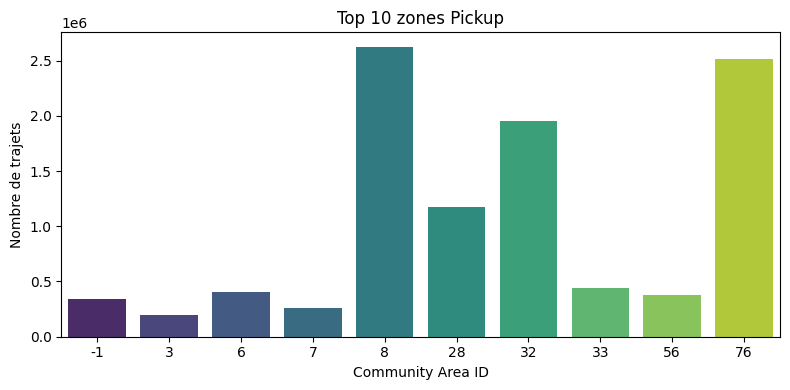

C:\Users\jbche\AppData\Local\Temp\ipykernel_24132\2953551151.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


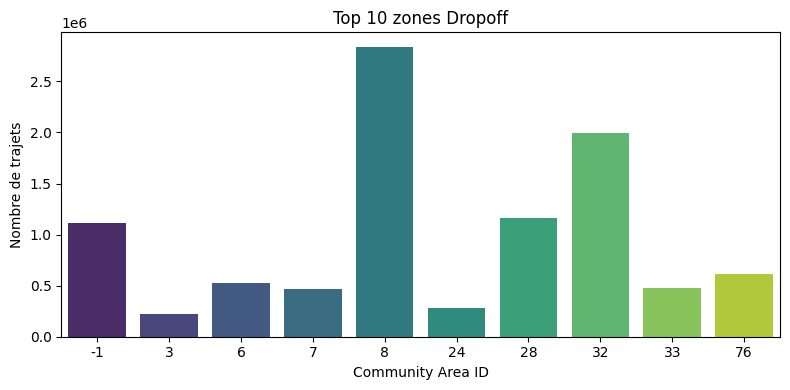

Nombre de Pickup = -1 : 339580
Nombre de Dropoff = -1 : 1109602


In [20]:
plt.figure(figsize=(8,4))
sns.barplot(
    x=pickup_counts.head(10).index.astype(int),
    y=pickup_counts.head(10).values,
    palette="viridis"
)
plt.title("Top 10 zones Pickup")
plt.xlabel("Community Area ID")
plt.ylabel("Nombre de trajets")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(
    x=dropoff_counts.head(10).index.astype(int),
    y=dropoff_counts.head(10).values,
    palette="viridis"
)
plt.title("Top 10 zones Dropoff")
plt.xlabel("Community Area ID")
plt.ylabel("Nombre de trajets")
plt.tight_layout()
plt.show()

# Analyse du code -1 (Unknown)
unk_pickup = (df["Pickup Community Area"] == -1).sum()
unk_dropoff = (df["Dropoff Community Area"] == -1).sum()

print(f"Nombre de Pickup = -1 : {unk_pickup}")
print(f"Nombre de Dropoff = -1 : {unk_dropoff}")


# <mark style="background: #01b3ffff;">Analyse Bivariée : Relation entre les variables</mark> 

##### Trip Miles vs Fare

In [39]:
for col in df.columns :
    print(col)

Unnamed: 0
Trip ID
Taxi ID
Trip Start Timestamp
Trip End Timestamp
Trip Seconds
Trip Miles
Pickup Community Area
Dropoff Community Area
Fare
Tips
Tolls
Extras
Trip Total
Payment Type
Company
start_hour
start_weekday
start_month
start_date
is_weekend
period_of_day
hour_sin
hour_cos
is_night
payment_freq
Payment Simplified
Company_clean
company_freq
pickup_freq
dropoff_freq


#### Trip Miles vs Fare : Prix hors pourboire,... vs Distance 

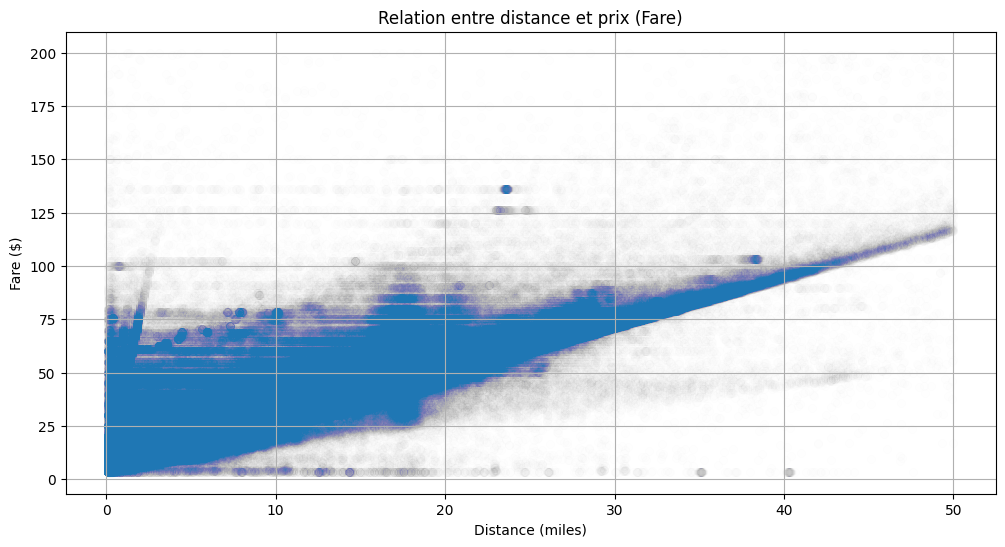

In [33]:
plt.figure(figsize=(12,6))
plt.scatter(df['Trip Miles'], df['Fare'], alpha=0.005)
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.title("Relation entre distance et prix (Fare)")
plt.grid()
plt.show()

- Tendance globale positive : le prix (Fare) augmente avec la distance parcourue, mais la relation n’est pas parfaitement linéaire.

- Forte dispersion (hétéroscédasticité) : la variabilité du prix augmente avec la distance, indiquant que de longs trajets peuvent coûter très différemment selon les conditions.

- Présence d’outliers :
    - distances courtes mais prix très élevés → potentiels frais supplémentaires (tolls/extras) ou erreurs

    - distances longues mais prix faibles → anomalies possibles

- Clusters identifiables : trajets courts urbains (0–5 miles), trajets moyens (5–20 miles).

- Relation non strictement linéaire : un modèle linéaire simple n’expliquerais pas forecement toute la variance il faut intégrer les extras, la durée, et les zones de départ/arrivée.

### Trip Seconds vs Fare : Durée en seconde vs Prix 

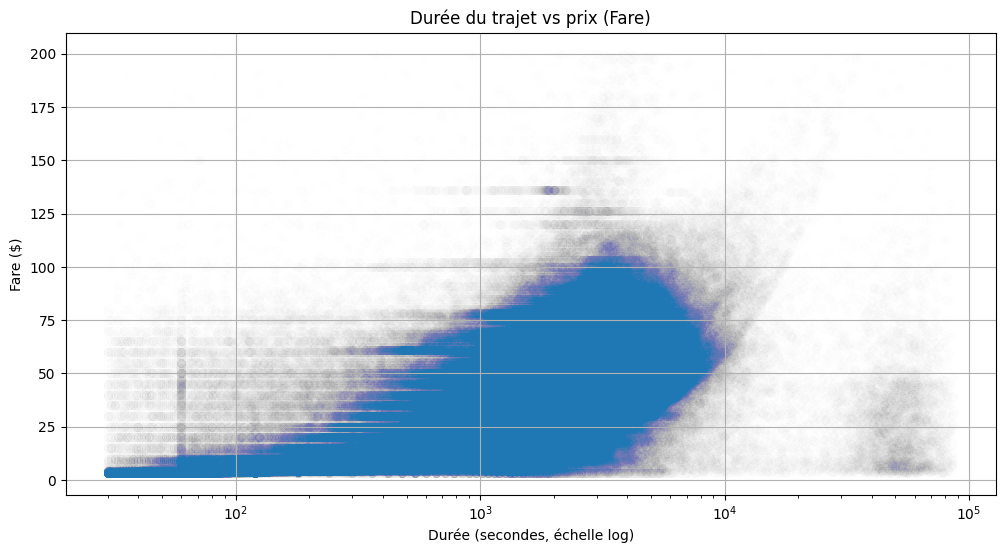

In [35]:
plt.figure(figsize=(12,6))
plt.scatter(df['Trip Seconds'], df['Fare'], alpha=0.005)
plt.xscale("log") # échelle logarithmique pour mieux visualiser
plt.xlabel("Durée (secondes, échelle log)")
plt.ylabel("Fare ($)")
plt.title("Durée du trajet vs prix (Fare)")
plt.grid()
plt.show()


- Tendance générale: Pas de relation strictement linéaire forte. La durée augmente parfois avec le Fare, mais la dispersion reste élevée.

- Échelle log: La transformation log met en évidence la forte concentration de trajets très courts (à gauche) ou les quelques trajet longs (à droite) et révèle mieux les patterns pour les durées longues.

- Plancher tarifaire: Beaucoup de points proches d’un tarif minimal pour les très courtes durées (tarif d’ouverture du compteur).

- Hétéroscédasticité: La variance du Fare augmente avec la durée, les longs trajets présentent à la fois des tarifs faibles et très élevés confirmant la rélation non lineaire entre ces deux variables.
Cas particuliers / outliers: Points avec Fare élevé et durée courte (vérifier extras/tolls/pourboires) ou durée longue avec Fare modéré (possible trafic/attente ou erreur de distance).

### Trip Miles vs Trip Seconds : Durée du trajet vs temps de trajet en seconde 

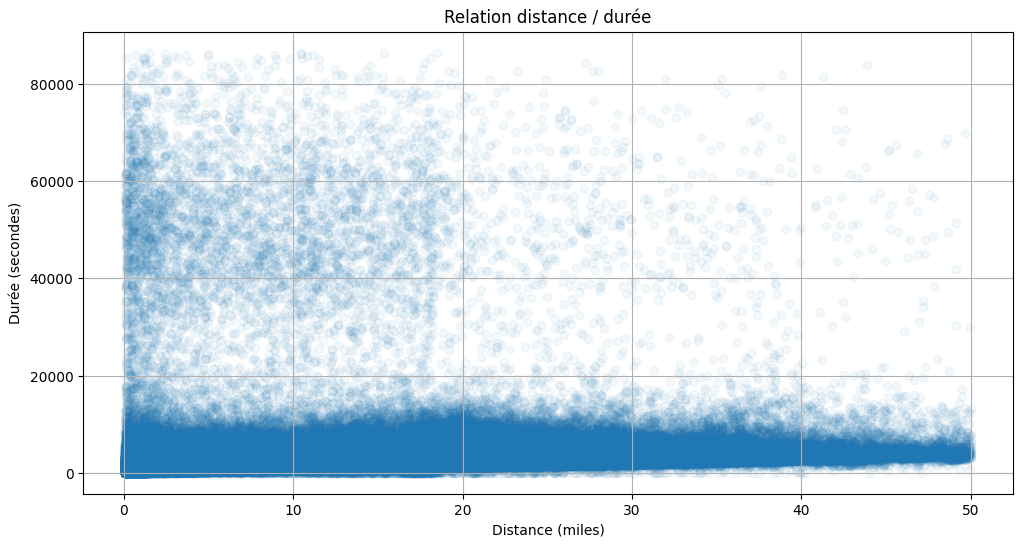

In [36]:
plt.figure(figsize=(12,6))
plt.scatter(df['Trip Miles'], df['Trip Seconds'], alpha=0.05)
plt.xlabel("Distance (miles)")
plt.ylabel("Durée (secondes)")
plt.title("Relation distance / durée")
plt.grid()
plt.show()



- relation globalement positive, plus la distance augmente, plus la durée augmente. La relation est proche d’une droite mais pas parfaite : forte dispersion autour de la tendance.

- Variabilité de vitesse : la dispersion verticale indique des vitesses très variables (trafic, arrêts, attente). Même pour distances similaires on observe durées très différentes.

- Clusters visibles : forte densité pour trajets courts (zone urbaine), puis un nuage plus diffus pour distances moyennes/longues.

- Outliers importants :
    - points avec durée élevée mais distance faible, attente/embouteillages ou erreurs de mesure ;
    - points avec distance élevée mais durée faible → possible erreur de timestamp/coordonnées ou trajets sur autoroute.
- Conséquences pour le nettoyage / features :
calcul de la vitesse : speed_mph = Trip Miles / (Trip Seconds/3600) et inspection de sa distribution ;

count    1.090422e+07
mean     1.846358e+01
std      1.487081e+01
min      4.636839e-03
25%      9.508541e+00
50%      1.507296e+01
75%      2.513006e+01
max      4.090909e+03
Name: speed_mph, dtype: float64


Text(0.5, 0, 'Vitesse (miles par heure)')

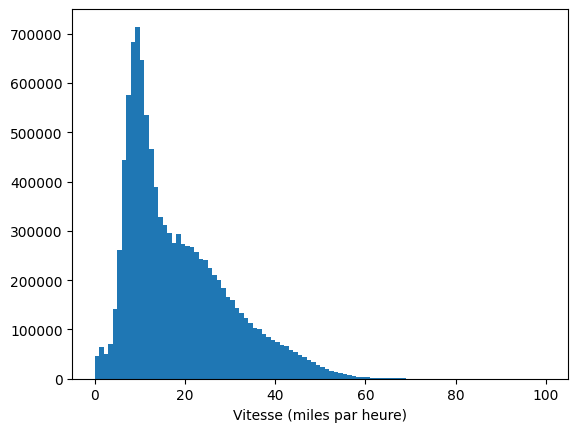

In [37]:
df["speed_mph"] = df["Trip Miles"] / (df["Trip Seconds"]/3600)
print(df["speed_mph"].describe())
plt.hist(df["speed_mph"], bins=100, range=(0,100))
plt.xlabel("Vitesse (miles par heure)")   

Le resultat montre clairement qu'il des outliers. La vitesse maximale semble aberante, et la min semble peu probable. Pour cela on va defenir des intervalles plutot realiste.

Text(0.5, 0, 'Vitesse (miles par heure)')

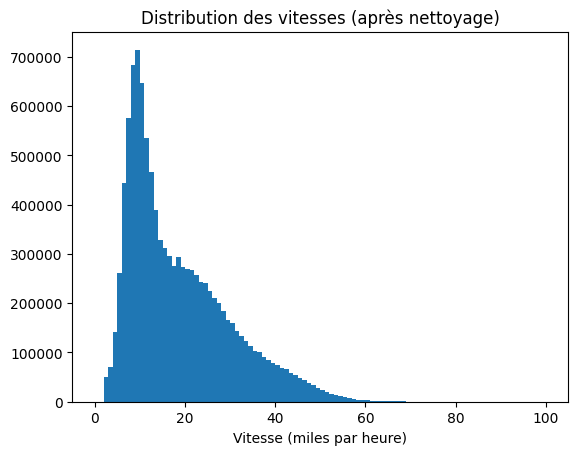

In [38]:
df = df[(df["speed_mph"] <= 200) & (df["speed_mph"] >= 2) ]  # garder trajets entre 2 et 100 mph
plt.title("Distribution des vitesses (après nettoyage)")            
plt.hist(df["speed_mph"], bins=100, range=(0,100))
plt.xlabel("Vitesse (miles par heure)") 


In [45]:
df["speed_mph"].describe()

count   10791709.000
mean          18.567
std           11.313
min            2.000
25%            9.616
50%           15.257
75%           25.250
max          200.000
Name: speed_mph, dtype: float64

#### Trip Miles vs Trip Total : Montant Total vs Distance 

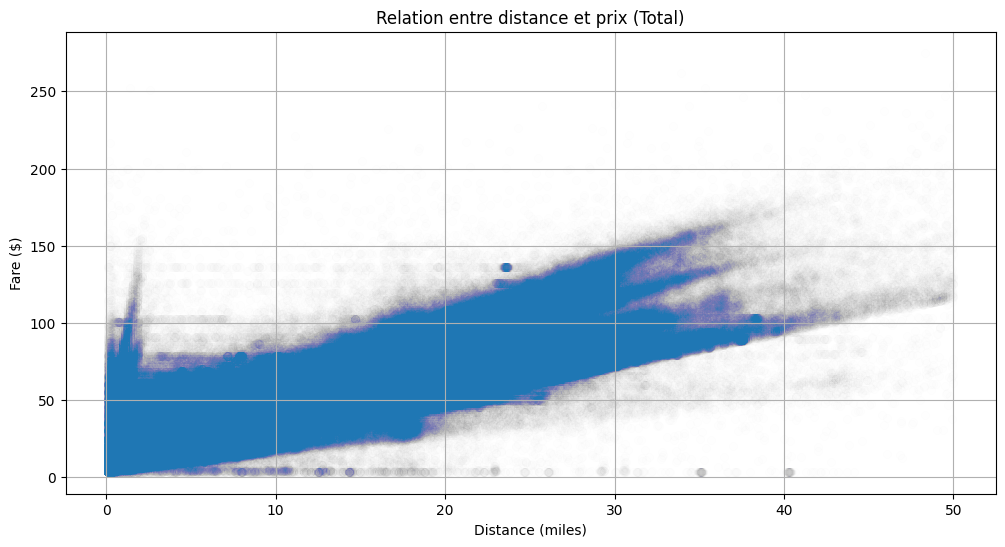

In [39]:
plt.figure(figsize=(12,6))
plt.scatter(df['Trip Miles'], df['Trip Total'], alpha=0.005)
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.title("Relation entre distance et prix (Total)")
plt.grid()
plt.show()

 - Résumé rapide : tendance globale positive, le Trip Total augmente en moyenne avec la distance, mais la dispersion est forte.

- Sources de variance supplémentaires : Trip Total inclut Tips, Tolls et Extras ; ces postes expliquent une grande part de la dispersion verticale (mêmes distances peuvent avoir des totaux très différents).
- Outliers / cas suspects : points avec Trip Total élevé pour distance courte (vérifier pourboires/péages/erreurs) ou distance élevée avec Trip Total faible (vérifier cohérence des données)

### Tips vs Payment : Pourboire vs Prix 

In [47]:
df["Tips"].groupby(df["Payment Type"]).describe()

,count,mean,std,min,25%,50%,75%,max
Payment Type,,,,,,,,
Cash,2508194.000,0.001,0.099,0.000,0.000,0.000,0.000,60.000
Credit Card,4137867.000,6.066,4.565,0.000,2.290,5.000,9.500,100.000
Mobile,2322860.000,2.468,2.954,0.000,0.000,2.000,3.090,74.740
Prcard,1414974.000,0.142,0.882,0.000,0.000,0.000,0.000,47.000
Unknown,407814.000,0.004,0.132,0.000,0.000,0.000,0.000,11.500


- Credit Card présente la médiane la plus élevée (~5$) et aussi la moyenne la plus haute (~6.0$).

- Mobile suit avec une médiane autour de 2$ (moyenne ~2.45$).

- Cash, Prcard et Unknown ont une médiane = 0$, ce qui indique que la grande majorité des trajets payés via ces méthodes n’incluent aucun tip

### Correlation entre quelques variables 

In [48]:
# Sélection des variables pertinentes
num_cols = [
    "Trip Miles",
    "Trip Seconds",
    "Fare",
    "Trip Total",
    "Tips",
    "Tolls",
    "Extras"
]

# Garder seulement les colonnes présentes dans ton df
num_cols = [c for c in num_cols if c in df.columns]
df_corr = df[num_cols].astype(float)

corr_matrix = df_corr.corr()
corr_matrix


,Trip Miles,Trip Seconds,Fare,Trip Total,Tips,Tolls,Extras
Trip Miles,1.000,0.754,0.954,0.930,0.537,0.090,0.451
Trip Seconds,0.754,1.000,0.776,0.730,0.426,0.039,0.264
Fare,0.954,0.776,1.000,0.953,0.521,0.083,0.412
Trip Total,0.930,0.730,0.953,1.000,0.692,0.131,0.627
Tips,0.537,0.426,0.521,0.692,1.000,0.080,0.446
Tolls,0.090,0.039,0.083,0.131,0.080,1.000,0.131
Extras,0.451,0.264,0.412,0.627,0.446,0.131,1.000


- En analysant la matrice de corrélation, plusieurs points clés se dégagent :

- La variable la plus déterminante est clairement la distance (Trip Miles), très fortement corrélée au tarif de base Fare (r ≈ 0.95). Cela confirme que le prix dépend principalement du nombre de miles parcourus.

- Trip Total est logiquement très corrélé à Trip Miles et Fare, puisque le montant total correspond au tarif de base auquel s’ajoutent tips, tolls et extras.

- Les pourboires (Tips) montrent une corrélation positive mais plus modérée avec Fare et Trip Total. Les clients ont tendance à laisser des pourboires plus élevés lors de trajets plus longs ou plus chers, mais le comportement reste en partie indépendant.

- Les péages (Tolls) jouent un rôle mineur dans l’explication de la variance : leurs corrélations sont faibles, ce qui montre qu’ils ne concernent qu’un type particulier de trajets.

- Les extras (Extras) présentent une corrélation modérée avec Fare et Trip Total, ce qui reflète leur logique : ils ajoutent des surcharges (nuit, aéroport, etc.) mais n’expliquent pas seuls la structure des prix.

A retenir 
- Forte multicolinéarité entre Trip Miles, Fare et Trip Total
Dans un modèle linéaire, il faudra éviter d’utiliser ces variables ensemble ou vérifier le VIF.

- Pour prédire le prix : c'est mieux d'utiliser des variables disponibles à l’avance (distance, durée, zones, horaires).


### Distribution des Community Areas pour pickups et dropoffs

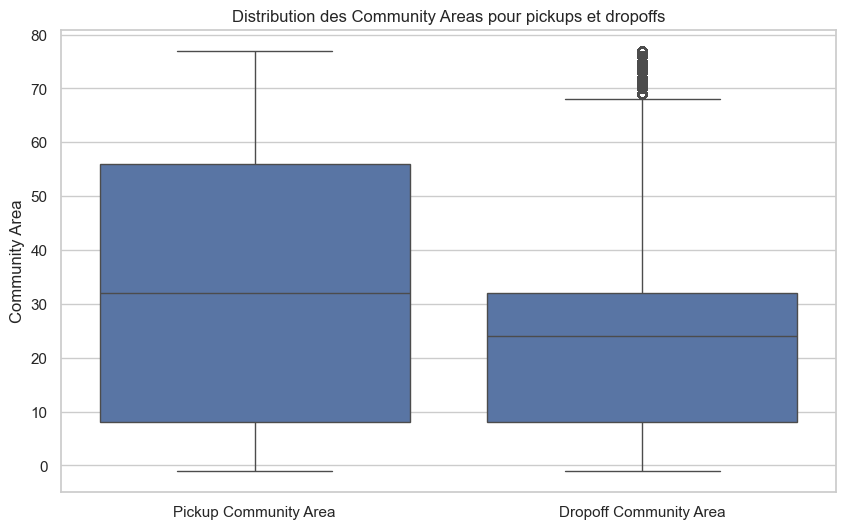

In [49]:
plt.figure(figsize=(10,6))

# On prépare les données pour seaborn
df_box = df[['Pickup Community Area', 'Dropoff Community Area']].melt(
    var_name='Type', value_name='Community Area'
)

# Boxplot
sns.boxplot(x='Type', y='Community Area', data=df_box)
plt.title("Distribution des Community Areas pour pickups et dropoffs")
plt.ylabel("Community Area")
plt.xlabel("")
plt.show()

On constate que les zones plus frequentes sont les zones de 10 a 50 pour le depart et 30 pour les drop out

### Courses par heure × zone

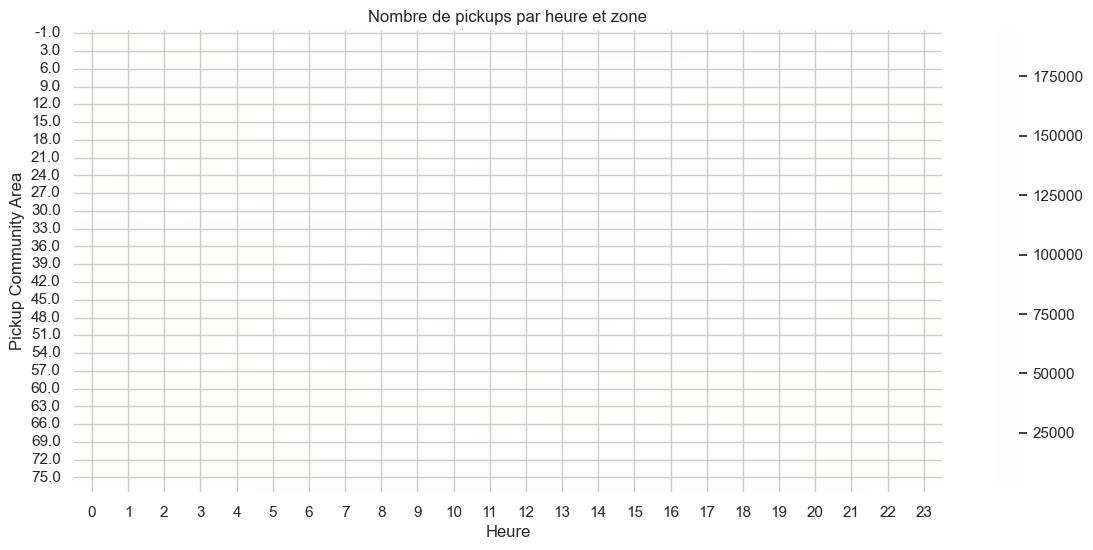

In [50]:
# Grouper par heure et zone
hourly_pickups = df.groupby(['start_hour', 'Pickup Community Area']).size().unstack(fill_value=0)

plt.figure(figsize=(14,6))
sns.heatmap(hourly_pickups.T, cmap='YlGnBu', alpha=0.005)
plt.title("Nombre de pickups par heure et zone")
plt.xlabel("Heure")
plt.ylabel("Pickup Community Area")
plt.show()

- Pattern principal : on observe des bandes horaires visibles, pics de pickups aux heures de pointe (matin & fin d’après‑midi) pour la majorité des zones, et creux la nuit.

- Zones actives vs périphériques : quelques Community Areas montrent des valeurs très élevées sur toute la journée (centre, aéroport), ce sont des hubs persistants ; d’autres ne bougent que sur des plages localisées (zones résidentielles le matin/soir).

- Décalages horaires locaux : certaines zones ont un pic tardif (vie nocturne) ou tôt (départs pour aéroport) ; utile pour repérer rôles fonctionnels des zones.

- Hétérogénéité spatiale : la variance entre zones est large, indique qu’il faut modéliser l’interaction heure × zone (features croisées ou agrégats par zone).

- Bruit et sparsité : de nombreuses zones montrent des valeurs proches de 0 hors leurs plages actives, envisager de regrouper les zones rares en Other pour la modélisation

### Identifier zones courtes/longues et fréquentes/rates

In [51]:
# Calcul distance moyenne et nombre de trajets par zone
zone_stats = df.groupby('Pickup Community Area').agg(
    avg_distance=('Trip Miles', 'mean'),
    num_trips=('Trip ID', 'count')
).reset_index()

In [52]:
# Zones avec trajets courts mais nombreux
short_frequent = zone_stats[(zone_stats['avg_distance'] < zone_stats['avg_distance'].median()) &
                            (zone_stats['num_trips'] > zone_stats['num_trips'].median())]

print("Zones avec trajets courts mais nombreux :")
print(short_frequent[['Pickup Community Area', 'avg_distance', 'num_trips']].head(10))

Zones avec trajets courts mais nombreux :
    Pickup Community Area  avg_distance  num_trips
1                   1.000         8.176      59420
2                   2.000         7.636      75795
3                   3.000         6.266     173913
4                   4.000         5.828      37423
5                   5.000         6.361      24563
6                   6.000         5.176     354462
7                   7.000         4.578     227114
8                   8.000         3.696    2358479
14                 14.000         7.046      18212
16                 16.000         7.928      33612


In [53]:
# Zones avec trajets longs mais rares
long_rare = zone_stats[(zone_stats['avg_distance'] > zone_stats['avg_distance'].median()) &
                       (zone_stats['num_trips'] < zone_stats['num_trips'].median())]

print("\nZones avec trajets longs mais rares :")
print(long_rare[['Pickup Community Area', 'avg_distance', 'num_trips']].head(10))


Zones avec trajets longs mais rares :
    Pickup Community Area  avg_distance  num_trips
9                   9.000         9.312       3252
12                 12.000         9.552      15900
18                 18.000         9.583       1258
26                 26.000        10.385       5079
29                 29.000         9.289      10029
30                 30.000        11.973       5964
37                 37.000         9.718      17624
45                 45.000         9.537      10052
47                 47.000        11.319       4028
48                 48.000         9.898      14061


## 7. Analyse de cohérence et détection d’anomalies
- Identifications anomalies :
  - Trip Seconds = 0 mais distance > 0
  - Fare = 0 mais distance > 0
  - Tolls > 0 pour des trajets courts urbains
- Détection des taxis ayant un comportement atypique :
  - nombre anormalement élevé de courses
  - distances très faibles répétées
  - durées systématiquement élevées

In [40]:
cond_anom = (
    (df["Fare"] == df["Fare"].min()) &
    (df["Trip Miles"] > df["Trip Miles"].mean())
)
cond_anom

0           False
1           False
2           False
3           False
4           False
            ...  
12204104    False
12204107    False
12204108    False
12204109    False
12204110    False
Length: 10791709, dtype: bool

On decide de virer les observation dont le trajet coute le min de Fare et la durée est superieur à la moyenne de Trip Miles car cela semble peu probable.

In [41]:
df = df[~cond_anom]

In [42]:
df[
    (df["Fare"] == df["Fare"].min()) &
    (df["Trip Miles"] > df["Trip Miles"].mean())
]


,Unnamed: 0,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,...,hour_sin,hour_cos,is_night,payment_freq,Payment Simplified,Company_clean,company_freq,pickup_freq,dropoff_freq,speed_mph


Après le traitement on constate que y'a plus d'observation qui respecte cette condition 

In [43]:
# Essayons de creer les sin et cos de weekday 
df['weekday_sin'] = np.sin(2 * np.pi * df['start_weekday']/7)  
df['weekday_cos'] = np.cos(2 * np.pi * df['start_weekday']/7)

# Essayons de creer les sin et cos de weekday 
df['month_sin'] = np.sin(2 * np.pi * (df['start_month']-1) / 12) # Sinon, janvier (1) et décembre (12) ne seront pas exactement voisins sur le cercle.
df['month_cos'] = np.cos(2 * np.pi * (df['start_month']-1) / 12)


In [44]:
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df.to_parquet("../data/df_taxi_parquet.parquet")

# <mark style="background: #01afffff;">Modélisation</mark> 


### <mark style="background: #01ff4dff;">Modélisation de Fare avec ElasticNet</mark> 


In [2]:
df_elasitc_net = pd.read_parquet("../data/df_taxi_parquet.parquet")

In [25]:
df_elasitc_net.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10791703 entries, 0 to 12204110
Data columns (total 36 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Unnamed: 0              int64         
 1   Trip ID                 object        
 2   Taxi ID                 object        
 3   Trip Start Timestamp    datetime64[ns]
 4   Trip End Timestamp      datetime64[ns]
 5   Trip Seconds            float64       
 6   Trip Miles              float64       
 7   Pickup Community Area   float64       
 8   Dropoff Community Area  float64       
 9   Fare                    float64       
 10  Tips                    float64       
 11  Tolls                   float64       
 12  Extras                  float64       
 13  Trip Total              float64       
 14  Payment Type            object        
 15  Company                 object        
 16  start_hour              int32         
 17  start_weekday           int32         
 18  start

In [3]:
X_final = [
    # Ride features (connues avant la course)
    "Trip Miles",  
    "Trip Seconds",          
    "start_hour",
    "start_weekday",
    "start_month",
    "is_weekend",
    "is_night",

    # Cyclical encodings
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",

    # Frequencies (proxies de demande/offre)
    "pickup_freq",
    "dropoff_freq",
    "company_freq"
    # "payment_freq",


]

target = "Fare"

variables_exclues = {
    "speed_mph": "Vitesse réelle calculée après la course, impossible à connaître en amont.",
    "Trip Total": "Inclus dynamiquement les tips, les extras et les ajustements post-course.",
    "Tolls": "Les péages réellement empruntés ne sont connus qu'après la course.",
    "Tips": "Variable déterminée par le client à la fin de la course.",
    "Extras": "Inclut suppléments appliqués en fin de course (fuel surcharge, bagages…).",
    "Company": "Trop de catégories → remplacé par company_freq (plus scalable).",
    "Pickup Community Area": "Trop de modalités → remplacé par pickup_freq.",
    "Dropoff Community Area": "Trop de modalités → remplacé par dropoff_freq.",
    "Payment Type": "Trop de catégories → remplacé par Payment Simplified + payment_freq.",
    "period_of_day": "Redondant avec start_hour et is_night.",
}


- Les variables liées au déroulement réel de la course (durée, vitesse, péages, pourboires, suppléments) ont été exclues afin d’éviter toute fuite d’information (data leakage).
- Dans une perspective de prédiction du tarif avant la course, seules les informations réellement disponibles au moment du pickup ont été conservées.

**ÉCHANTILLON DE 1 MILLION:**

In [4]:
df_1m = df_elasitc_net.sample(n=1_000_000, random_state=42)

# Stratification en 10 quantiles
df_1m["fare_strata"] = pd.qcut(df_1m[target], q=10, duplicates='drop').cat.codes

- Un échantillon aléatoire de 1 000 000 observations est extrait du dataset complet afin de réduire la charge computationnelle. Cet échantillonnage permet de conserver une représentativité statistique tout en rendant la cross-validation possible sur une machine locale.
- Pour assurer une répartition équilibrée de la variable cible dans les différents jeux d'entraînement et de validation, la variable Fare est transformée en classes via un découpage en déciles (10 quantiles). pd.qcut crée des intervalles, puis .cat.codes les convertit en entiers exploitables par les méthodes de stratification.
- Cette stratification est utilisée lors du split train/test et lors de la cross-validation, ce qui garantit que chaque sous-ensemble possède une distribution similaire de valeurs de Fare. Cela stabilise les estimations des performances et évite que certains folds contiennent uniquement des trajets très peu chers ou très chers.
- Cette procédure est cohérente avec la liste des variables explicatives X_final : la stratification porte uniquement sur la variable cible Fare et ne crée aucun risque de fuite d'information, et l’échantillonnage n’altère pas les propriétés des features retenues pour la modélisation Elastic Net.

**TRAIN / TEST SPLIT (STRATIFIÉ) :**

In [5]:
X_small = df_1m[X_final]
y_small = df_1m[target]
strata = df_1m["fare_strata"]

X_train_small, X_test_small, y_train_small, y_test_small, strata_train, strata_test = train_test_split(
    X_small,
    y_small,
    strata,
    test_size=0.2,
    random_state=42,
    stratify=strata
)


- Extraction du jeu de features X_small à partir des variables explicatives retenues (X_final).
- Définition de la variable cible y_small correspondant à Fare.
- Récupération de la variable de stratification strata, qui représente les quantiles du prix et permet de garantir l’équilibre des distributions de la cible dans les différents sous-échantillons.
- Séparation de l’échantillon d’un million d’observations en un jeu d’entraînement (80 %) et un jeu de test (20 %).
- La stratification est réalisée à l’aide de la variable strata, ce qui impose que les distributions des quantiles de Fare soient similaires dans les deux sous-échantillons.
- Le résultat contient les données explicatives et cibles pour l’entraînement et le test, ainsi que les variables de stratification correspondantes, utiles pour des vérifications éventuelles.

**SCALING :**

In [6]:
alphas = [0.0005, 0.001, 0.01, 0.1]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

strata_train_q = pd.qcut(y_train_small, q=10, duplicates="drop").cat.codes

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_rmse = float("inf")
best_alpha = None
best_l1 = None
best_r2_cv = None
best_mae_cv = None

for a in alphas:
    for l1 in l1_ratios:

        rmses = []
        r2s = []
        maes = []

        # === CROSS-VALIDATION PROPRE SANS LEAKAGE ===
        for train_idx, val_idx in kf.split(X_train_small, strata_train_q):

            # Données brutes du fold
            X_tr_raw = X_train_small.iloc[train_idx]
            X_val_raw = X_train_small.iloc[val_idx]

            y_tr = y_train_small.iloc[train_idx]
            y_val = y_train_small.iloc[val_idx]

            # Scaling sans leakage
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_raw)    # fit uniquement sur le TRAIN du fold
            X_val = scaler.transform(X_val_raw)      # transform du VAL


            # Modèle
            model = ElasticNet(alpha=a, l1_ratio=l1, max_iter=20000)
            model.fit(X_tr, y_tr)

            pred = model.predict(X_val)

            # Scores du fold
            rmses.append(root_mean_squared_error(y_val, pred))
            r2s.append(r2_score(y_val, pred))
            maes.append(mean_absolute_error(y_val, pred))

        # Scores moyens pour cette paire (alpha, l1_ratio)
        avg_rmse = np.mean(rmses)
        avg_r2 = np.mean(r2s)
        avg_mae = np.mean(maes)

        # Mise à jour du meilleur modèle
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_alpha = a
            best_l1 = l1
            best_r2_cv = avg_r2
            best_mae_cv = avg_mae


- Une grille de valeurs possibles est définie pour les hyperparamètres d’Elastic Net : alpha (force de régularisation) et l1_ratio (poids entre L1 et L2).
- La variable cible du jeu d’entraînement est découpée en 10 quantiles afin de créer une stratification utilisable par StratifiedKFold. Cette stratification garantit que chaque fold contient une distribution similaire de valeurs de Fare.
- Une cross-validation à 5 folds est définie : à chaque itération, un fold sert de validation et les quatre autres d’entraînement.
- Pour chaque combinaison (alpha, l1_ratio), le modèle Elastic Net est entraîné sur les folds d’entraînement et évalué sur le fold de validation.
- Trois métriques sont calculées sur chaque fold : RMSE, R² et MAE. On stocke ensuite leur moyenne sur les 5 folds.
- La combinaison d’hyperparamètres qui minimise la moyenne des RMSE est conservée comme la meilleure, et les métriques correspondantes (R² moyen et MAE moyen) sont également enregistrées.

**TRAIN METRICS :**

In [7]:
print("\n===== CROSS-VALIDATION RESULTS =====")
print("Best alpha :", best_alpha)
print("Best l1_ratio :", best_l1)
print("Best CV RMSE :", best_rmse)
print("Best CV MAE :", best_mae_cv)
print("Best CV R²  :", best_r2_cv)

# ===== FINAL SCALING (propre) =====
final_scaler = StandardScaler()
X_train_small_scaled = final_scaler.fit_transform(X_train_small)  # fit sur tout le train
X_test_small_scaled  = final_scaler.transform(X_test_small)       # transform sur test

# ===== FINAL MODEL FIT =====
best_model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=20000)
best_model.fit(X_train_small_scaled, y_train_small)

# ===== TRAIN METRICS =====
y_pred_train = best_model.predict(X_train_small_scaled)

rmse_train = root_mean_squared_error(y_train_small, y_pred_train)
mae_train = mean_absolute_error(y_train_small, y_pred_train)
r2_train = r2_score(y_train_small, y_pred_train)

print("\n===== TRAIN METRICS =====")
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("R² :", r2_train)

# ===== TEST METRICS =====
y_pred_test = best_model.predict(X_test_small_scaled)

rmse_test = root_mean_squared_error(y_test_small, y_pred_test)
mae_test = mean_absolute_error(y_test_small, y_pred_test)
r2_test = r2_score(y_test_small, y_pred_test)

print("\n===== TEST METRICS =====")
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("R² :", r2_test)



===== CROSS-VALIDATION RESULTS =====
Best alpha : 0.001
Best l1_ratio : 0.9
Best CV RMSE : 4.7547073570628475
Best CV MAE : 1.8534774919699017
Best CV R²  : 0.9180847965594777

===== TRAIN METRICS =====
RMSE: 4.7541073466891435
MAE: 1.853272001543151
R² : 0.9181072124495672

===== TEST METRICS =====
RMSE: 4.801824706917543
MAE: 1.8542863030363925
R² : 0.9169257579926609


- Le paramètre alpha = 0.0005 indique une régularisation très faible. Une valeur basse est cohérente avec un dataset très volumineux : plus le nombre d’observations est grand, plus le modèle peut apprendre des relations stables sans nécessiter une forte pénalisation. Un alpha élevé aurait sous-ajusté le modèle en supprimant trop de variance utile.

- Le paramètre l1_ratio = 0.7 montre que l’Elastic Net applique principalement une régularisation de type L1 (lasso). Cela signifie que le modèle privilégie la sélection de variables en mettant certains coefficients proches de zéro. Dans ce contexte, où seules des variables pertinentes et peu corrélées ont été retenues dans X_final, il est logique que la partie L1 domine, car elle stabilise le modèle tout en conservant un ensemble restreint de coefficients significatifs.

- La combinaison alpha faible et l1_ratio élevé est cohérente pour un modèle linéaire entraîné sur un grand volume de données avec peu de bruit structurel : la régularisation n’est pas trop forte pour permettre un bon ajustement, mais suffisamment orientée L1 pour éviter des coefficients instables ou non pertinents.

In [8]:
coefs = best_model.coef_


importance = np.abs(coefs)

feat_imp = pd.DataFrame({
    "feature": X_train_small.columns,
    "coef": coefs,
    "importance": importance
})

feat_imp = feat_imp.sort_values("importance", ascending=False)

feat_imp.head(20)


,feature,coef,importance
0,Trip Miles,14.115946,14.115946
1,Trip Seconds,2.261471,2.261471
13,pickup_freq,-0.274337,0.274337
15,company_freq,0.242922,0.242922
6,is_night,0.124730,0.124730
8,hour_cos,0.111582,0.111582
12,month_cos,-0.058611,0.058611
2,start_hour,-0.051032,0.051032
5,is_weekend,0.049878,0.049878
11,month_sin,-0.045957,0.045957


C:\Users\jbche\AppData\Local\Temp\ipykernel_4828\920636745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


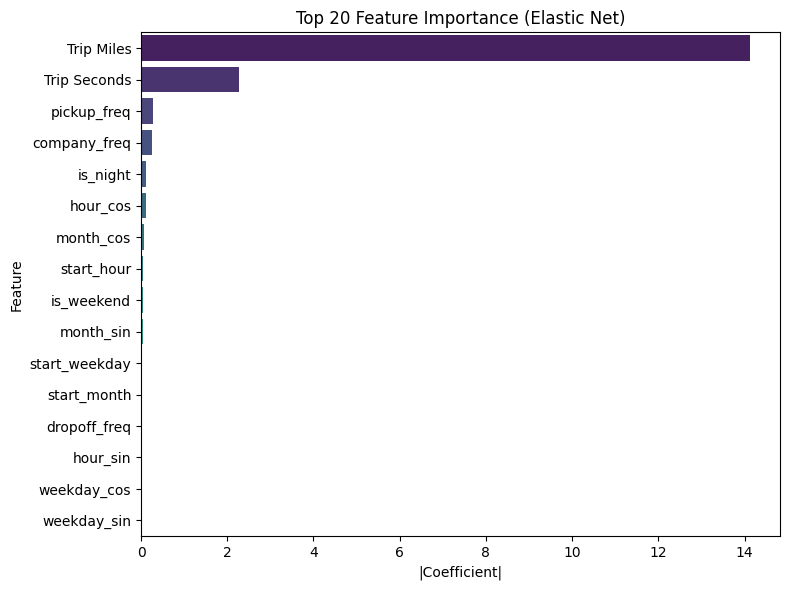

In [9]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp.head(20),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 Feature Importance (Elastic Net)")
plt.xlabel("|Coefficient|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


- Les deux variables les plus importantes sont Trip Miles et Trip Seconds. Trip Miles domine largement le modèle, ce qui est cohérent car la distance est le déterminant structurel du prix d’une course, tandis que Trip Seconds apporte une information complémentaire liée au temps passé dans le trafic.

- Les variables de fréquence (pickup_freq, company_freq, dropoff_freq) occupent une place significative, ce qui indique que certains points de départ, compagnies ou zones de dépose sont associés à des trajets typiquement plus longs ou plus coûteux. 

- Les variables temporelles (is_night, start_hour, is_weekend, month_sin/cos) ont une importance modérée mais réelle. Cela confirme que l’heure et la période influencent les conditions de circulation ou les habitudes de déplacement, ce qui affecte le prix via la durée et la distance. 

- Les encodages sinusoïdaux pour les heures et les mois apportent un complément d’information mais restent moins influents que les variables brutes. Enfin, les variables liées au jour de la semaine (weekday_sin/cos) ont une importance très faible, ce qui montre que le jour précis importe peu une fois que les autres variables sont prises en compte.

- Dans l’ensemble, l’importance des variables est cohérente avec la logique du problème : la distance et la durée expliquent l’essentiel, les variables de fréquence ajoutent une structure comportementale, et le contexte temporel affine la prédiction de manière secondairee.


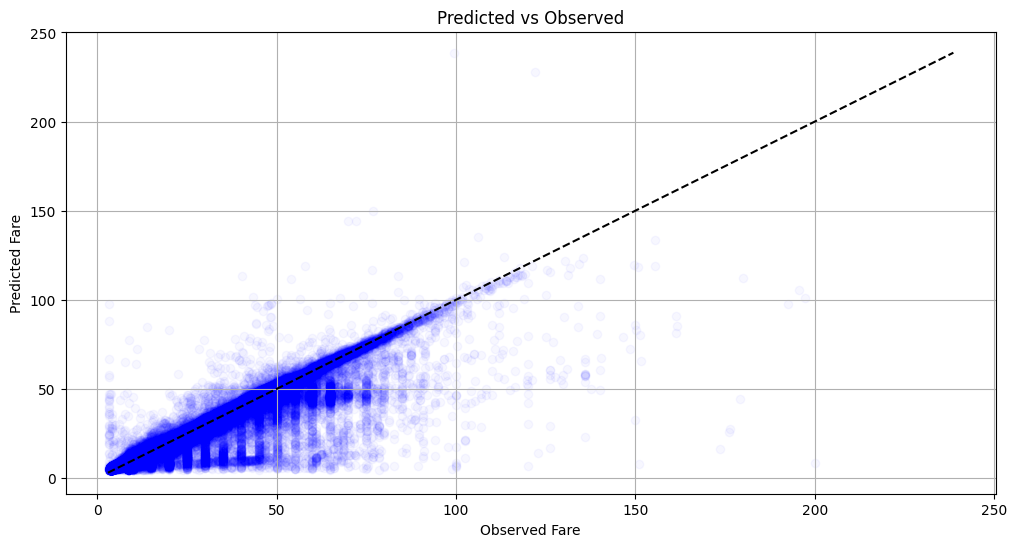

In [10]:
plt.figure(figsize=(12,6))
plt.scatter(y_test_small, y_pred_test, alpha=0.03,c="blue")

# ligne 45° pour repère
min_val = min(y_test_small.min(), y_pred_test.min())
max_val = max(y_test_small.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--",c="black")

plt.xlabel("Observed Fare")
plt.ylabel("Predicted Fare")
plt.title("Predicted vs Observed")
plt.grid(True)
plt.show()


les points du graphique représentent les prédictions, positionnées en fonction des valeurs vraies sur l’axe X.

### <mark style="background: #01ff4dff;">Modélisation de Fare avec XGBOOST</mark> 


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10791703 entries, 0 to 12204110
Data columns (total 32 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Unnamed: 0              int64         
 1   Trip ID                 object        
 2   Taxi ID                 object        
 3   Trip Start Timestamp    datetime64[ns]
 4   Trip End Timestamp      datetime64[ns]
 5   Trip Seconds            float64       
 6   Trip Miles              float64       
 7   Pickup Community Area   float64       
 8   Dropoff Community Area  float64       
 9   Fare                    float64       
 10  Tips                    float64       
 11  Tolls                   float64       
 12  Extras                  float64       
 13  Trip Total              float64       
 14  Payment Type            object        
 15  Company                 object        
 16  start_hour              int32         
 17  start_weekday           int32         
 18  start

Pourquoi company_freq et pas company_clean ? 

- company_freq est : une variable numérique unique qui encode la popularité de la compagnie corrélée à son importance réelle dans le dataset simple, compacte, non sparse

- XGBoost va naturellement apprendre :
    - si les grosses compagnies facturent plus ou moins
    - si certaines compagnies tournent plus dans certaines zones
    - si la distance, durée, zones interagissent différemment selon la compagnie


In [58]:
features = [
    'Trip Seconds',
    'Trip Miles',
    #'Pickup Community Area',
    #'Dropoff Community Area',
    #'start_hour',     
    "hour_sin",
    "hour_cos",
    'start_weekday', # à encodder par sin et cos
    'start_month', # à encodder par in et cos
    'is_weekend',  # deja encodder 
    #'is_night'
    'period_of_day',
    # 'payment_freq',
    'company_freq',
    'pickup_freq',
    'dropoff_freq'
]

In [60]:
features = [
    'Trip Seconds',
    'Trip Miles',
    #'Pickup Community Area',
    #'Dropoff Community Area',
    #'start_hour',     
    "hour_sin",
    "hour_cos",
    #"start_weekday",
    "weekday_sin",
    'weekday_cos', 
    #'start_month', 
    "month_sin", 
    "month_cos",
    'is_weekend',  # deja encodder 
    #'is_night'
    'period_of_day',
    # 'payment_freq',
    'company_freq',
    'pickup_freq',
    'dropoff_freq'
]

In [63]:
X = df[features]
y = df["Fare"]
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [64]:
# ===== MODELE XGBOOST =====
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",  # plus rapide pour grands datasets
    enable_categorical=True,
    random_state=42
)

# ===== TRAIN =====
model.fit(X_train, y_train)
pred_train = model.predict(X_train)

print("===== TRAIN =====")
print("MAE :", mean_absolute_error(y_train, pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, pred_train)))
print("R²  :", r2_score(y_train, pred_train))

# ===== CROSS-VALIDATION (2-fold, échantillon pour accélérer) =====
# Sous-échantillon pour réduire le temps de CV
sample_frac = 0.1  # 10% du train
X_train_sample = X_train.sample(frac=sample_frac, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

kf = KFold(n_splits=2, shuffle=True, random_state=42)

mae_scores = -cross_val_score(model, X_train_sample, y_train_sample,
                              cv=kf, scoring='neg_mean_absolute_error')
rmse_scores = np.sqrt(-cross_val_score(model, X_train_sample, y_train_sample,
                                       cv=kf, scoring='neg_mean_squared_error'))
r2_scores = cross_val_score(model, X_train_sample, y_train_sample, cv=kf, scoring='r2')

print("\n===== CROSS-VALIDATION (2-fold, 10% train sample) =====")
print("MAE :", mae_scores.mean())
print("RMSE:", rmse_scores.mean())
print("R²  :", r2_scores.mean())

# ===== TEST =====
pred_test = model.predict(X_test)
print("\n===== TEST =====")
print("MAE :", mean_absolute_error(y_test, pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))
print("R²  :", r2_score(y_test, pred_test))

===== TRAIN =====
MAE : 1.6076399548248284
RMSE: 4.157356372911562
R²  : 0.9373924411358694

===== CROSS-VALIDATION (2-fold, 10% train sample) =====
MAE : 1.6508925891559745
RMSE: 4.264932015951808
R²  : 0.9340797296786998

===== TEST =====
MAE : 1.6105942996380724
RMSE: 4.1696229936015525
R²  : 0.937072459067217


In [66]:
explainer = shap.Explainer(model)
rng = np.random.default_rng(seed=78512)
sample = rng.choice(X_test.index, size=int(len(X_test)* 0.001), replace=False)
X_test_sample = X_test.loc[sample, :]
shap_values = explainer.shap_values(X_test_sample)

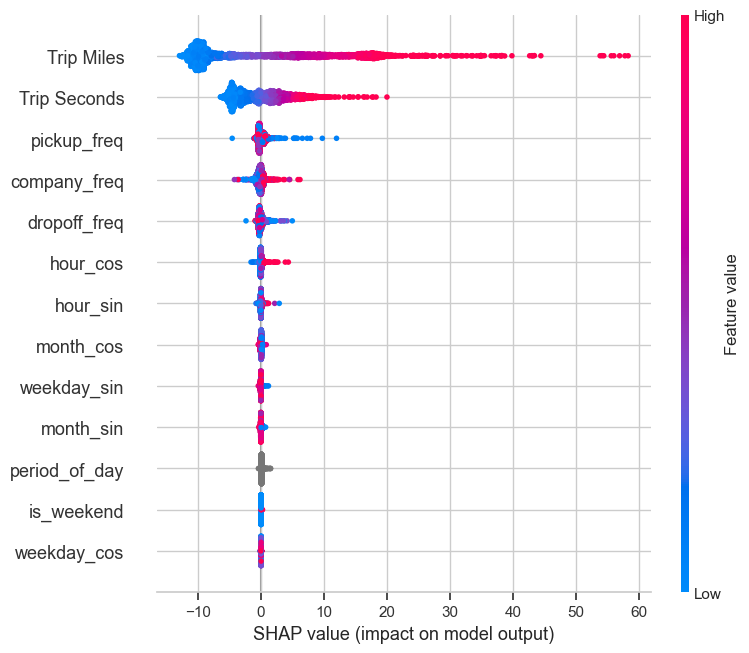

In [71]:
shap.summary_plot(shap_values, X_test_sample,) 

L'axe des ordonnées indique les noms des caractéristiques par ordre d'importance, de haut en bas.
L'axe X représente la valeur SHAP, qui indique le degré de changement dans le logarithme des cotes.
La couleur de chaque point du graphique représente la valeur de l'élément correspondant, le rouge indiquant les valeurs élevées et le bleu les valeurs faibles.
Chaque point représente une ligne de données de l'ensemble de données original.